# 1.3 — Análise Exploratória dos Dados Meteorológicos

Este notebook realiza uma análise exploratória completa dos dados do projeto Climate Intelligence Engine.
O objetivo é entender a estrutura, qualidade, padrões e relações dos dados antes de qualquer modelagem.

**Datasets utilizados:**
- `stations.parquet` — metadados das 663 estações
- `weather_measurements.parquet` — medições horárias de 2000 a 2025
- `station_distances.parquet` — distâncias par-a-par entre estações

**Ao final, o notebook é exportado automaticamente para PDF.**

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('data')

MEASURE_COLS = [
    'temperature', 'humidity', 'rainfall', 'global_radiation',
    'pressure', 'dew_point', 'wind_speed', 'wind_gust', 'wind_direction'
]

MEASURE_LABELS = {
    'temperature':      'Temperatura (°C)',
    'humidity':         'Umidade (%)',
    'rainfall':         'Chuva (mm)',
    'global_radiation': 'Radiação (KJ/m²)',
    'pressure':         'Pressão (hPa)',
    'dew_point':        'Ponto de Orvalho (°C)',
    'wind_speed':       'Vel. Vento (m/s)',
    'wind_gust':        'Rajada (m/s)',
    'wind_direction':   'Dir. Vento (°)',
}

colors = ['tomato','steelblue','royalblue','goldenrod','mediumpurple',
          'teal','gray','slategray','darkorange']

## 1. Carga dos Dados

In [2]:
stations = pd.read_parquet(DATA_DIR / 'stations.parquet')
stations['latitude']  = stations['latitude'].astype(float)
stations['longitude'] = stations['longitude'].astype(float)
stations['altitude']  = stations['altitude'].astype(float)

measurements = pd.read_parquet(DATA_DIR / 'weather_measurements.parquet')
measurements['measurement_time'] = pd.to_datetime(measurements['measurement_time'])
measurements['year']  = measurements['measurement_time'].dt.year
measurements['month'] = measurements['measurement_time'].dt.month
measurements['hour']  = measurements['measurement_time'].dt.hour

distances = pd.read_parquet(DATA_DIR / 'station_distances.parquet')

print('=== Ficha Técnica do Dataset ===')
print(f'Estações              : {len(stations):,}')
print(f'Registros de medição  : {len(measurements):,}')
print(f'Período               : {measurements["measurement_time"].min().date()} → {measurements["measurement_time"].max().date()}')
print(f'Anos cobertos         : {measurements["year"].nunique()}')
print(f'Pares de distância    : {len(distances):,}')
print(f'Estados cobertos      : {stations["state"].nunique()}')
print(f'Altitude mín / máx    : {stations["altitude"].min():.0f} m / {stations["altitude"].max():.0f} m')

=== Ficha Técnica do Dataset ===
Estações              : 663
Registros de medição  : 83,153,626
Período               : 2000-05-07 → 2025-12-31
Anos cobertos         : 26
Pares de distância    : 438,906
Estados cobertos      : 27
Altitude mín / máx    : 0 m / 1790 m


---
## 1.1 Estatísticas Descritivas

Antes de qualquer análise visual, é fundamental entender os números centrais de cada variável.
Esta seção apresenta média, desvio padrão, quartis, assimetria e curtose.

**O que esperar:** variáveis como temperatura e pressão devem ter distribuições próximas do normal.
Chuva e radiação tendem a ser fortemente assimétricas à direita (muitas horas com valor zero ou baixo e poucos eventos extremos).

In [3]:
desc = measurements[MEASURE_COLS].describe().T
desc['skewness'] = measurements[MEASURE_COLS].skew()
desc['kurtosis'] = measurements[MEASURE_COLS].kurt()
desc['null_%']   = measurements[MEASURE_COLS].isnull().mean() * 100
desc.index = [MEASURE_LABELS[c] for c in desc.index]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,null_%
Temperatura (°C),70748950.0,23.39,5.62,-9.6,20.1,23.60,27.1,45.0,-0.34,0.40,14.92
Umidade (%),68917440.0,71.76,20.29,7.0,58.0,76.00,89.0,100.0,-0.67,-0.45,17.12
Chuva (mm),66941238.0,0.16,1.29,0.0,0.0,0.00,0.0,138.2,17.94,484.51,19.50
Radiação (KJ/m²),69190117.0,831.36,1713.54,-43.0,-3.4,39.07,1457.6,51588.0,11.01,204.48,16.79
Pressão (hPa),70683132.0,964.84,37.85,802.0,938.7,969.30,996.8,1050.0,-0.71,0.19,15.00
Ponto de Orvalho (°C),68784392.0,17.17,4.87,-42.5,14.2,18.10,20.9,45.0,-0.95,1.69,17.28
Vel. Vento (m/s),68260804.0,1.99,1.70,0.0,0.7,1.70,2.9,43.4,1.31,3.47,17.91
Rajada (m/s),68207439.0,4.86,3.05,0.0,2.5,4.50,6.8,50.0,0.73,1.07,17.97
Dir. Vento (°),67918855.0,154.01,98.35,0.0,76.0,131.00,230.0,360.0,0.51,-0.84,18.32


### 1.1.1 Assimetria e Curtose por Variável

**Assimetria (skewness):** valores próximos de 0 indicam distribuição simétrica. Valores positivos altos indicam cauda longa à direita (ex: chuva). Valores negativos indicam cauda à esquerda.

**Curtose:** mede o 'pico' da distribuição. Valores altos indicam distribuições leptocúrticas (pico agudo, caudas pesadas), como pode ocorrer em rajadas de vento e chuva intensa.

**O que esperar:** `rainfall` e `global_radiation` devem ter assimetria muito alta. `temperature` e `pressure` devem ser próximas de zero.

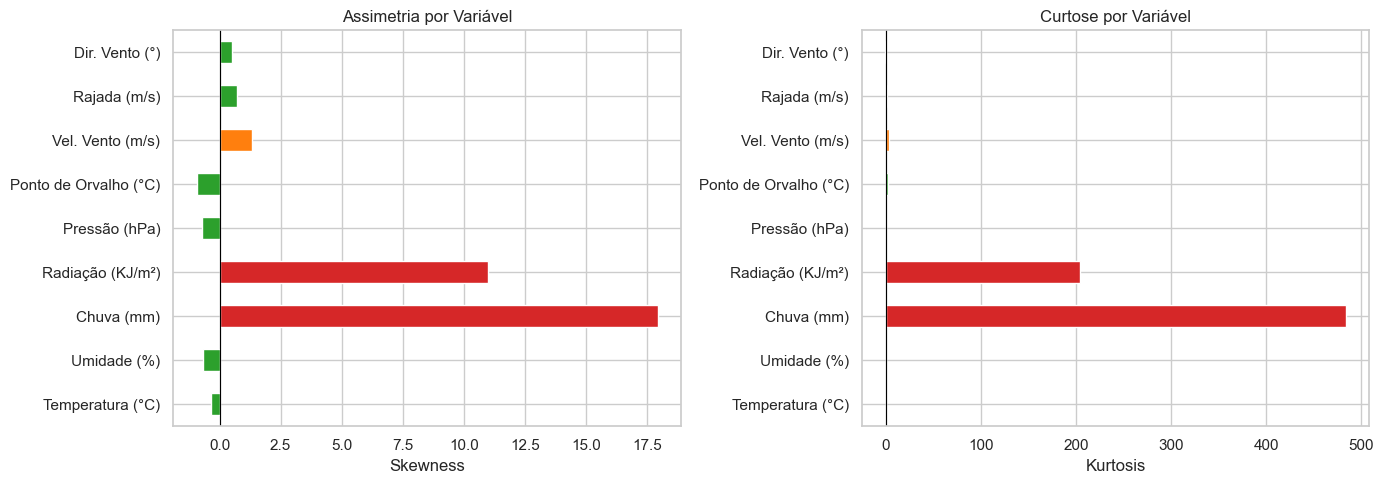

In [4]:
skew_kurt = pd.DataFrame({
    'Assimetria': measurements[MEASURE_COLS].skew(),
    'Curtose':    measurements[MEASURE_COLS].kurt(),
})
skew_kurt.index = [MEASURE_LABELS[c] for c in skew_kurt.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_skew = ['#d62728' if abs(v) > 2 else '#ff7f0e' if abs(v) > 1 else '#2ca02c'
               for v in skew_kurt['Assimetria']]
skew_kurt['Assimetria'].plot(kind='barh', ax=axes[0], color=colors_skew)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Assimetria por Variável')
axes[0].set_xlabel('Skewness')

colors_kurt = ['#d62728' if v > 10 else '#ff7f0e' if v > 3 else '#2ca02c'
               for v in skew_kurt['Curtose']]
skew_kurt['Curtose'].plot(kind='barh', ax=axes[1], color=colors_kurt)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Curtose por Variável')
axes[1].set_xlabel('Kurtosis')

plt.tight_layout()
plt.show()

### 1.1.2 Distribuição de Cada Variável — Histograma + KDE

Visualiza a forma da distribuição de cada variável meteorológica.
A linha KDE (Kernel Density Estimate) suaviza o histograma e facilita identificar bimodalidade, skew e outliers.

**O que esperar:** temperatura deve ter forma aproximadamente gaussiana com possível bimodalidade regional. Chuva e radiação solar devem ter pico em zero e longa cauda à direita.

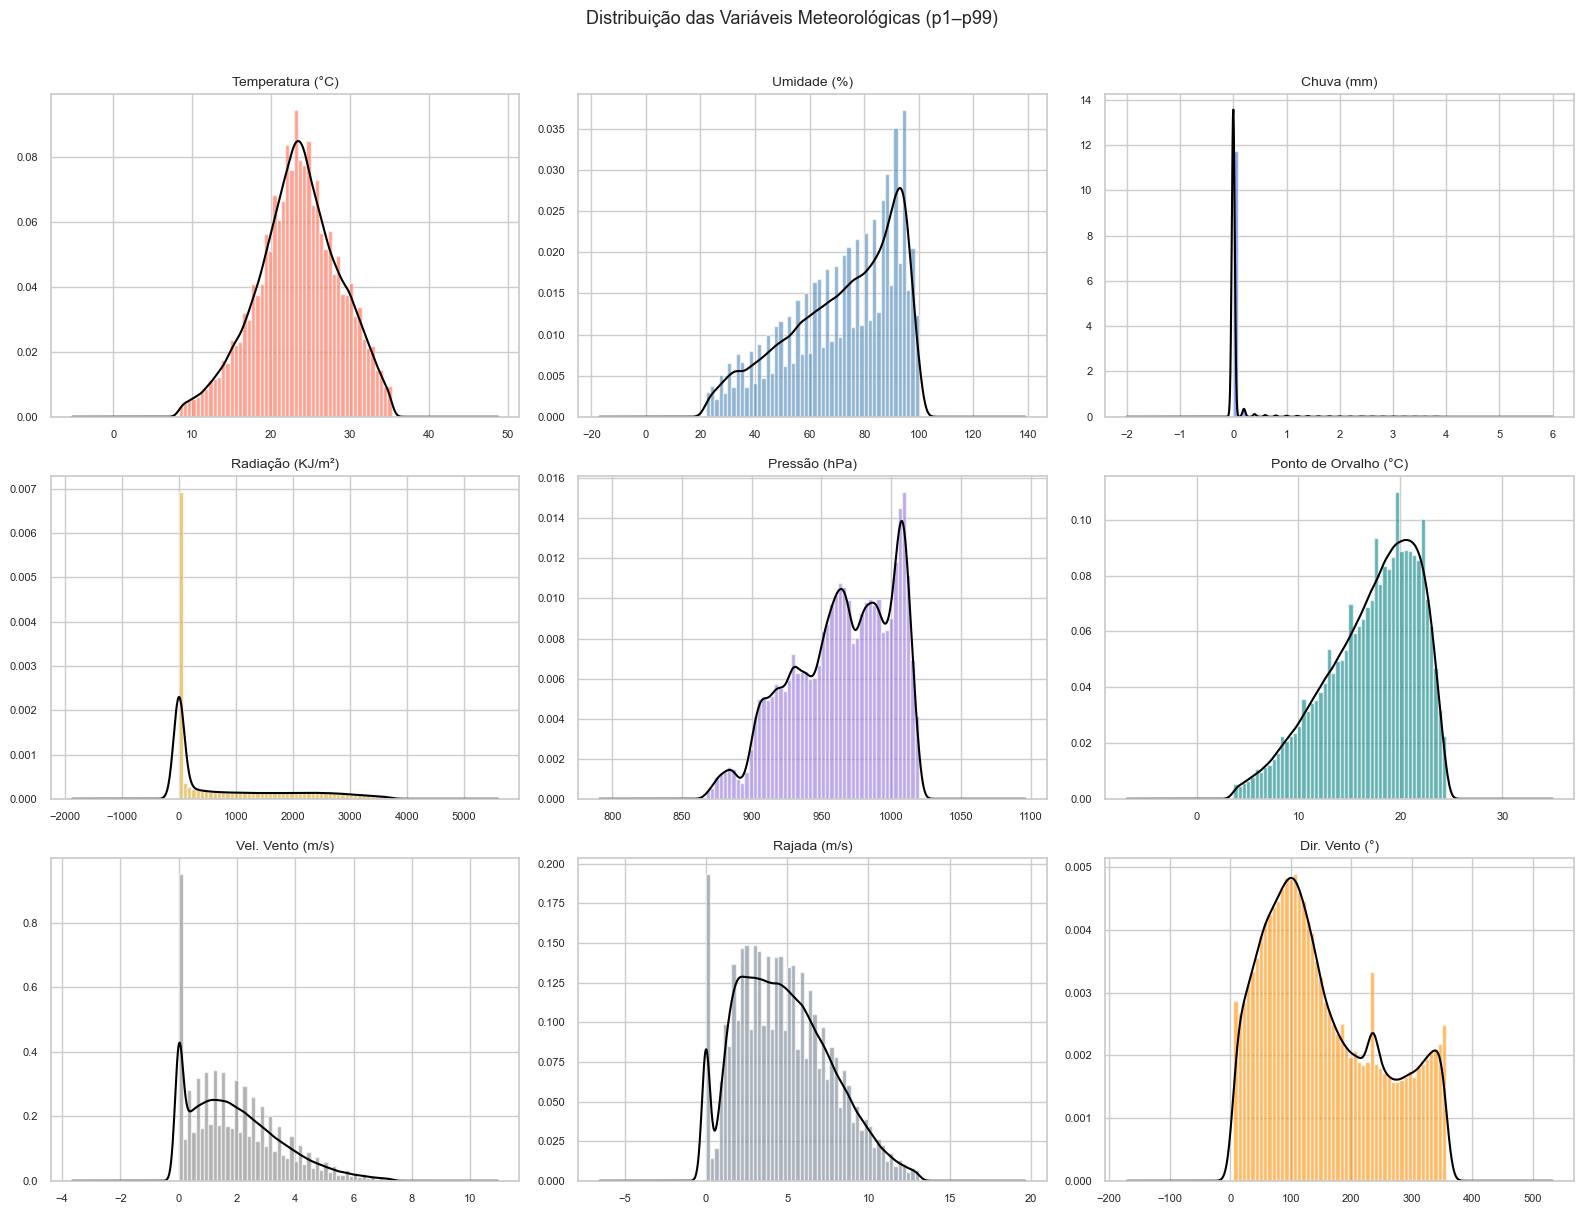

In [5]:
sample = measurements[MEASURE_COLS].dropna().sample(min(200_000, len(measurements)), random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col, color in zip(axes.flat, MEASURE_COLS, colors):
    data = sample[col].dropna()
    p01, p99 = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= p01) & (data <= p99)]
    ax.hist(clipped, bins=50, density=True, color=color, alpha=0.6, edgecolor='white')
    clipped.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.set_title(MEASURE_LABELS[col], fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

fig.suptitle('Distribuição das Variáveis Meteorológicas (p1–p99)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.1.3 Boxplots por Variável

O boxplot mostra mediana, IQR (intervalo interquartil), mínimo/máximo e outliers de forma compacta.
É especialmente útil para comparar a dispersão e a presença de valores extremos entre variáveis.

**O que esperar:** `wind_gust`, `rainfall` e `global_radiation` devem ter muitos outliers superiores,
dado seu caráter episódico (eventos extremos pontuais).

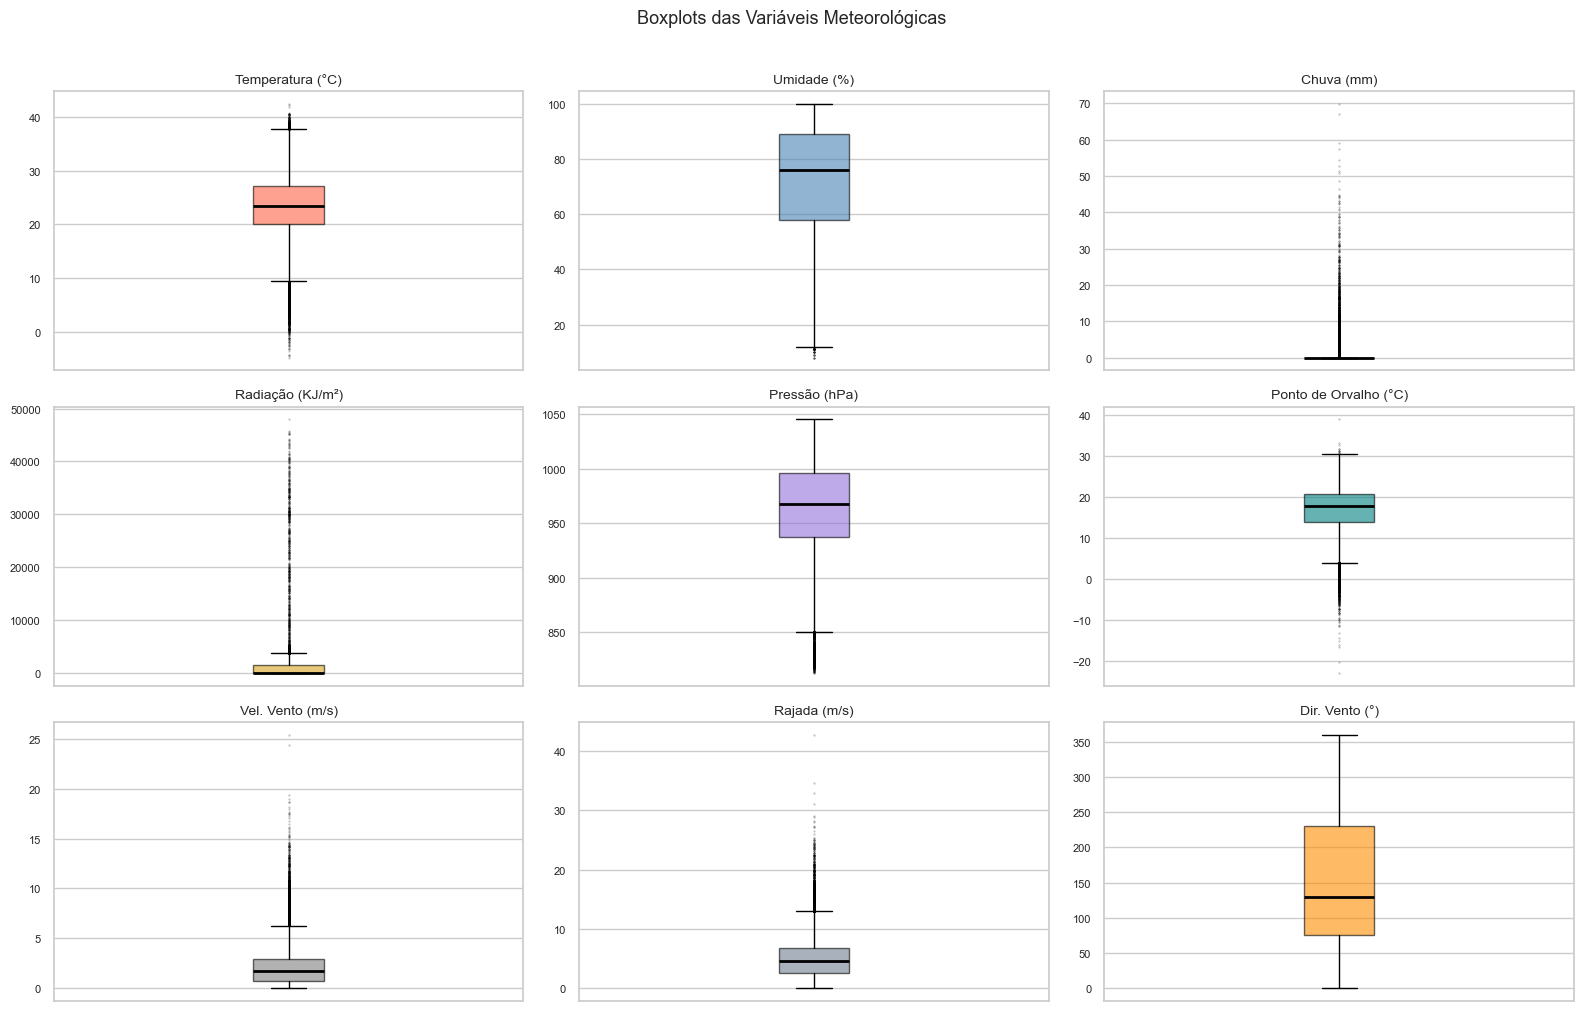

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for ax, col, color in zip(axes.flat, MEASURE_COLS, colors):
    data = sample[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', markersize=1, alpha=0.3, color=color))
    ax.set_title(MEASURE_LABELS[col], fontsize=10)
    ax.set_xticks([])
    ax.tick_params(labelsize=8)

fig.suptitle('Boxplots das Variáveis Meteorológicas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.1.4 Evolução do Volume de Dados ao Longo do Tempo

Mostra quantos registros não-nulos existem por ano em cada variável.
Permite identificar quando a rede de estações se expandiu, períodos de falha generalizada
e possíveis problemas de coleta em anos específicos.

**O que esperar:** crescimento gradual do volume até ~2015 com a expansão da rede INMET,
seguido de estabilização. Quedas abruptas indicam falhas sistêmicas ou mudanças no protocolo de coleta.

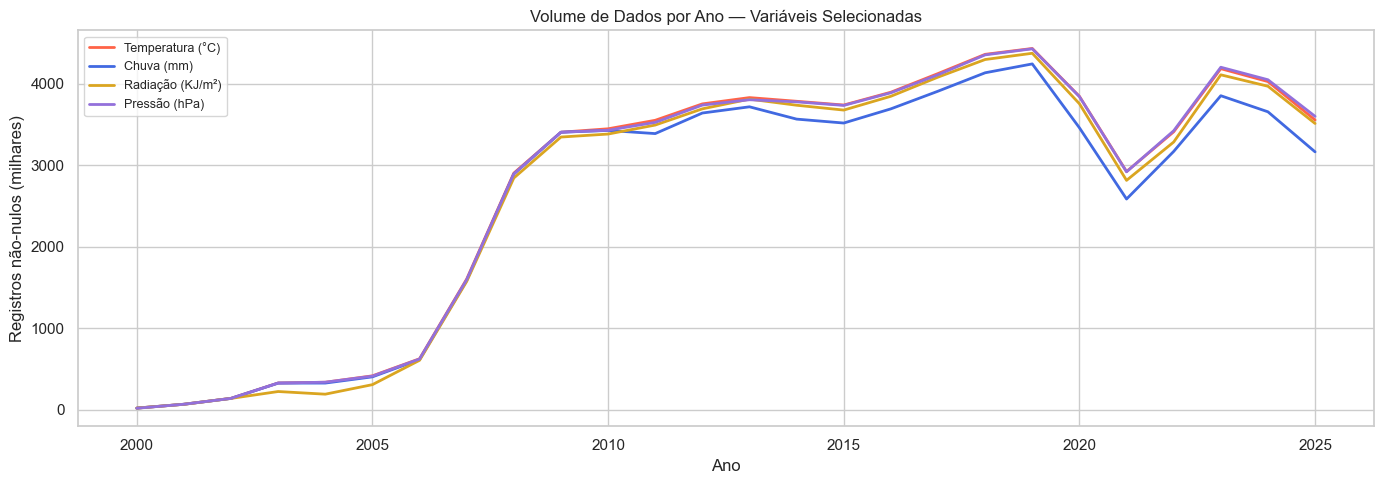

In [7]:
yearly = measurements.groupby('year')[MEASURE_COLS].count()

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(['temperature', 'rainfall', 'global_radiation', 'pressure'],
                      ['tomato', 'royalblue', 'goldenrod', 'mediumpurple']):
    ax.plot(yearly.index, yearly[col] / 1_000, label=MEASURE_LABELS[col], linewidth=2, color=color)

ax.set_xlabel('Ano')
ax.set_ylabel('Registros não-nulos (milhares)')
ax.set_title('Volume de Dados por Ano — Variáveis Selecionadas')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Qualidade dos Dados

Antes de usar os dados para modelagem ou análise, é essencial entender onde e quanto falta.
Esta seção quantifica os dados ausentes, inconsistências físicas e cobertura temporal por estação.

### 2.1 Taxa de NaN por Variável

Percentual de valores ausentes em cada variável sobre o total de registros.
Verde = menos de 10% faltante (aceitável), laranja = 10–30% (requer atenção), vermelho = acima de 30% (crítico).

**O que esperar:** `global_radiation` e `wind_direction` tendem a ter mais NaN por serem sensores
com maior taxa de falha. `temperature` e `pressure` costumam ser os mais completos.

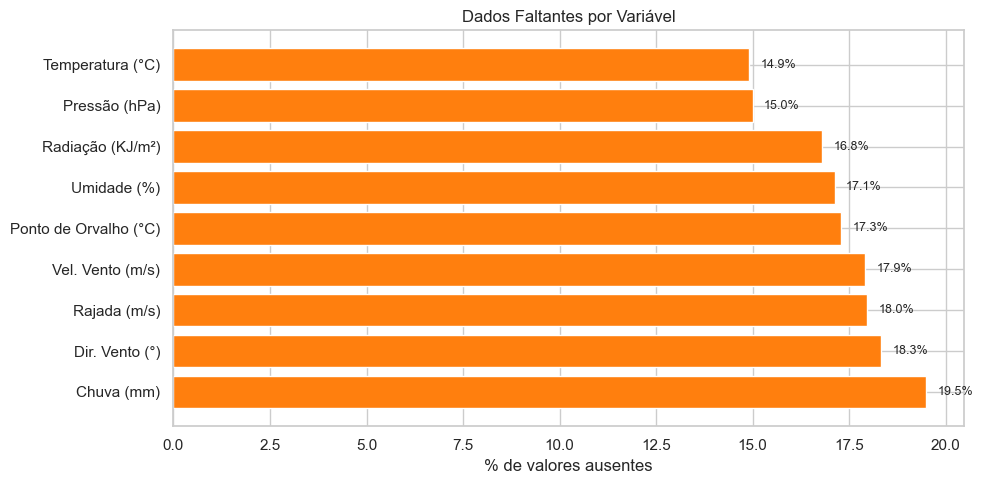

In [8]:
null_pct = measurements[MEASURE_COLS].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#d62728' if v > 30 else '#ff7f0e' if v > 10 else '#2ca02c' for v in null_pct.values]
bars = ax.barh([MEASURE_LABELS[c] for c in null_pct.index], null_pct.values, color=bar_colors)
ax.set_xlabel('% de valores ausentes')
ax.set_title('Dados Faltantes por Variável')
for bar, val in zip(bars, null_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.2 Taxa de NaN por Estação — Top 30 Piores

Identifica quais estações têm maior proporção de dados ausentes, considerando a média de todas as variáveis.
Estações com alta taxa de NaN podem precisar ser excluídas ou tratadas com cautela em modelos.

**O que esperar:** estações mais recentes (inauguradas após 2015) ou em regiões remotas
costumam ter menos dados simplesmente por terem operado por menos tempo.

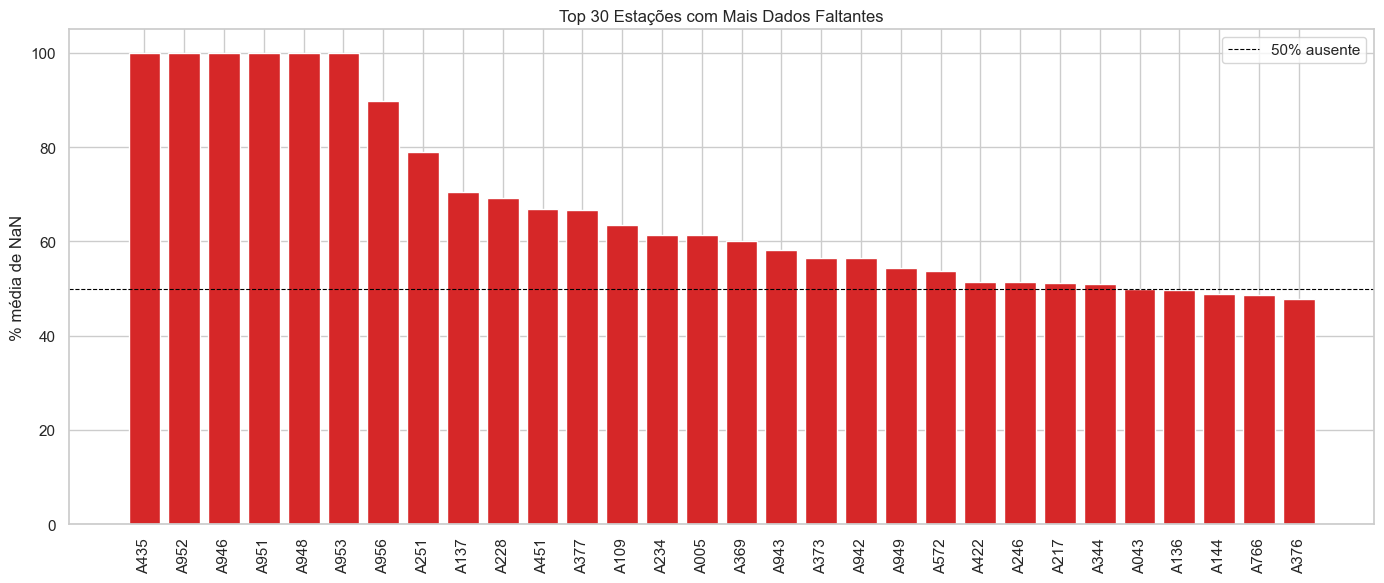

In [9]:
null_by_station = (
    measurements.groupby('station_code')[MEASURE_COLS]
    .apply(lambda x: x.isnull().mean() * 100)
)
null_by_station['mean_null'] = null_by_station.mean(axis=1)
top_null = null_by_station['mean_null'].sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(top_null.index, top_null.values, color='#d62728')
ax.axhline(50, color='black', linestyle='--', linewidth=0.8, label='50% ausente')
ax.set_ylabel('% média de NaN')
ax.set_title('Top 30 Estações com Mais Dados Faltantes')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Heatmap de NaN — Estação × Variável

Mostra simultaneamente quais variáveis e quais estações têm mais dados faltantes.
Padrões horizontais (uma estação ruim em todas as variáveis) indicam estação com problema geral.
Padrões verticais (uma variável ruim em todas as estações) indicam sensor com falha sistêmica.

**O que esperar:** padrões mistos, com algumas estações ruins em todas as variáveis
e algumas variáveis consistentemente piores.

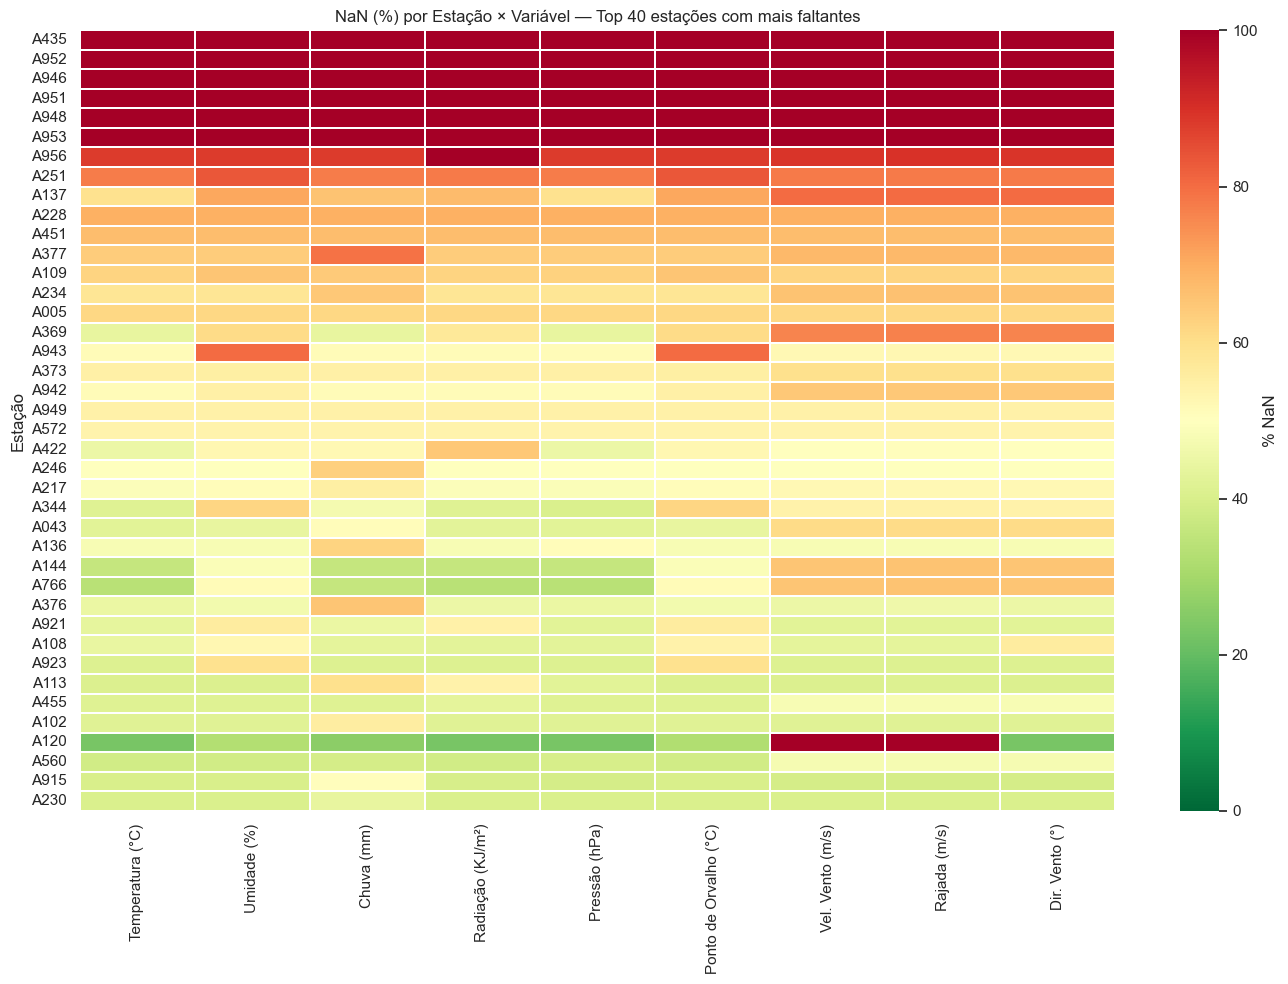

In [10]:
sample_stations = null_by_station['mean_null'].sort_values(ascending=False).head(40).index
heatmap_data = null_by_station.loc[sample_stations, MEASURE_COLS]
heatmap_data.columns = [MEASURE_LABELS[c] for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap='RdYlGn_r', vmin=0, vmax=100,
            linewidths=0.3, ax=ax, cbar_kws={'label': '% NaN'}, annot=False)
ax.set_title('NaN (%) por Estação × Variável — Top 40 estações com mais faltantes')
ax.set_xlabel('')
ax.set_ylabel('Estação')
plt.tight_layout()
plt.show()

### 2.4 Cobertura Temporal por Estação

Mostra a distribuição de quantos anos cada estação possui dados e quando cada uma começou a operar.
É importante para entender se uma estação com poucos dados é nova ou sofreu interrupção.

**O que esperar:** pico de inaugurações entre 2007 e 2012 (expansão da rede INMET automática).
Poucas estações com cobertura superior a 20 anos.

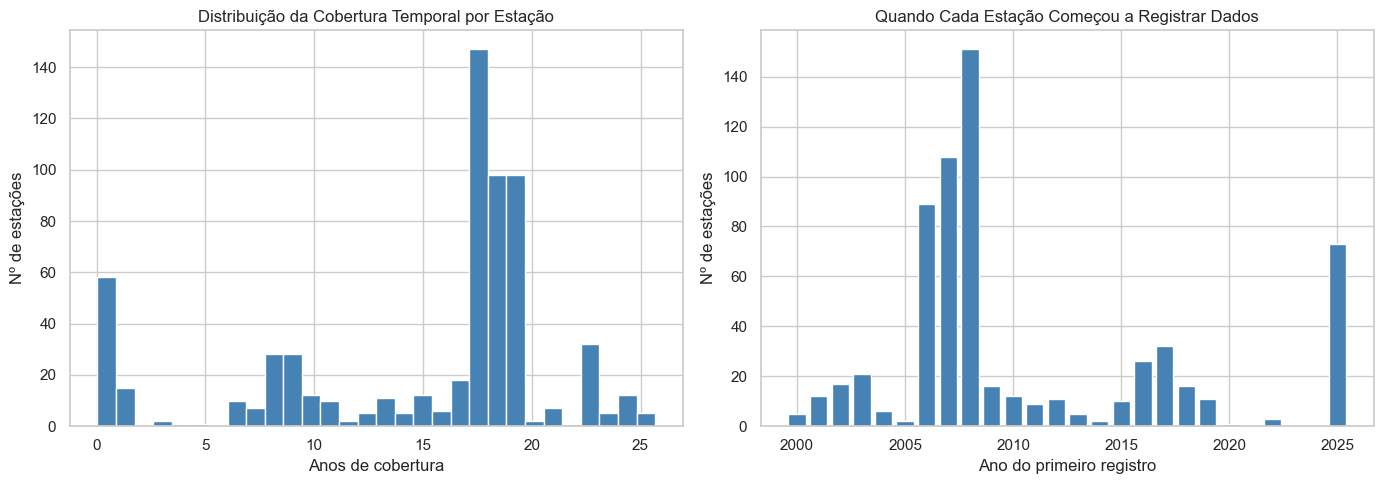

In [11]:
coverage = measurements.groupby('station_code')['measurement_time'].agg(['min', 'max'])
coverage['days'] = (coverage['max'] - coverage['min']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(coverage['days'] / 365, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Anos de cobertura')
axes[0].set_ylabel('Nº de estações')
axes[0].set_title('Distribuição da Cobertura Temporal por Estação')

years = coverage['min'].dt.year.value_counts().sort_index()
axes[1].bar(years.index, years.values, color='steelblue')
axes[1].set_xlabel('Ano do primeiro registro')
axes[1].set_ylabel('Nº de estações')
axes[1].set_title('Quando Cada Estação Começou a Registrar Dados')

plt.tight_layout()
plt.show()

### 2.5 Padrão Temporal de Dados Faltantes por Estação

Mostra a completude de `temperature` mês a mês para cada estação ao longo de toda a série histórica.
Diferente do heatmap estático (2.3), este revela **quando** os gaps ocorrem:
se são blocos contínuos de meses/anos ou falhas isoladas.

Esta análise é essencial para o gap-filling: um gap de 2 horas pode ser preenchido por interpolação,
enquanto um gap de 6 meses exige estações proxy.

**O que esperar:** estações mais antigas com dados desde 2000. Estações novas com bloco vermelho
no início (antes de entrarem em operação). Algumas estações com interrupções longas no meio da série,
indicando paradas de manutenção ou falha de equipamento.

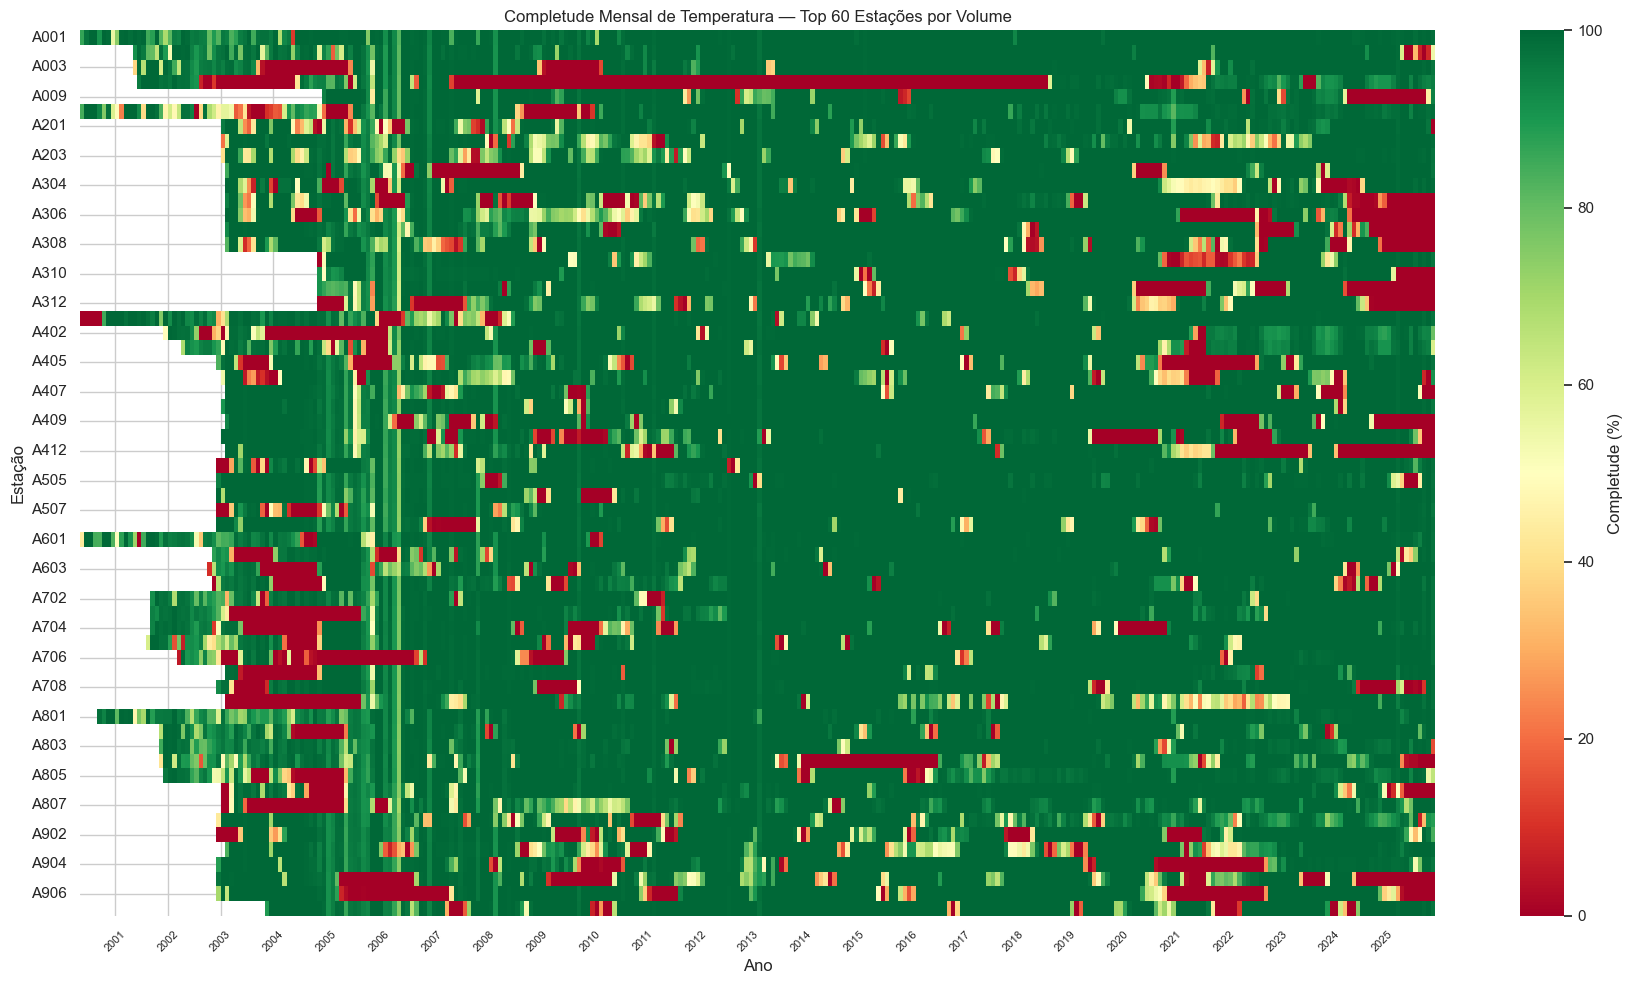

In [12]:
top_stations = measurements['station_code'].value_counts().head(60).index
m_sub = measurements[measurements['station_code'].isin(top_stations)].copy()
m_sub['year_month'] = m_sub['measurement_time'].dt.to_period('M')

monthly_comp = (
    m_sub.groupby(['year_month', 'station_code'])['temperature']
    .apply(lambda x: x.notna().mean() * 100)
    .unstack('station_code')
)

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    monthly_comp.T,
    cmap='RdYlGn', vmin=0, vmax=100,
    ax=ax, cbar_kws={'label': 'Completude (%)'},
    xticklabels=False, linewidths=0,
)
year_ticks  = [i for i, p in enumerate(monthly_comp.index) if p.month == 1]
year_labels = [str(monthly_comp.index[i].year) for i in year_ticks]
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, fontsize=8)
ax.set_xlabel('Ano')
ax.set_ylabel('Estação')
ax.set_title('Completude Mensal de Temperatura — Top 60 Estações por Volume')
plt.tight_layout()
plt.show()

### 2.6 Detecção de Outliers Físicos

Verifica quantos registros estão fora de limites fisicamente plausíveis para o Brasil.
Esses valores não são apenas extremos estatísticos — são impossíveis ou altamente improváveis
do ponto de vista meteorológico e indicam erros de sensor ou de entrada de dados.

**O que esperar:** poucos outliers físicos na maioria das variáveis. Umidade acima de 100%
ou abaixo de 0% é um erro claro. Pressões abaixo de 700 hPa ou acima de 1100 hPa são impossíveis ao nível do mar.

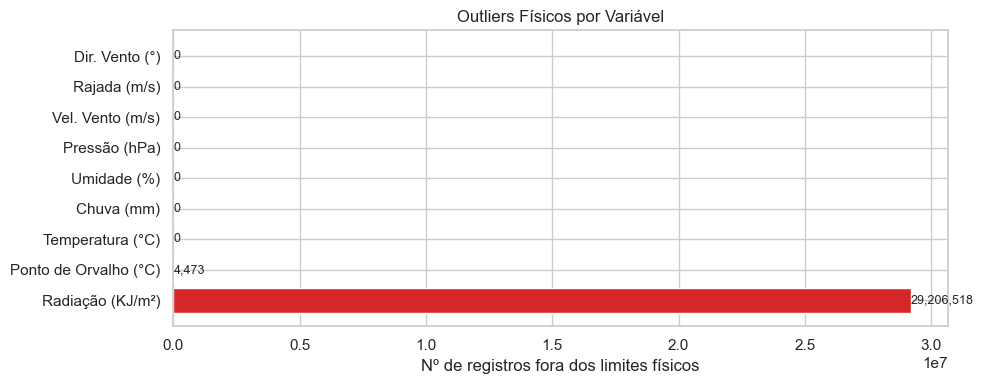

In [13]:
physical_bounds = {
    'temperature':      (-20,  60),
    'humidity':         (  0, 100),
    'rainfall':         (  0, 500),
    'global_radiation': (  0, 5000),
    'pressure':         (700, 1100),
    'dew_point':        (-30,  40),
    'wind_speed':       (  0, 100),
    'wind_gust':        (  0, 150),
    'wind_direction':   (  0, 360),
}

outlier_counts = {}
for col, (lo, hi) in physical_bounds.items():
    valid = measurements[col].dropna()
    outlier_counts[col] = ((valid < lo) | (valid > hi)).sum()

outlier_df = pd.Series(outlier_counts)
outlier_df.index = [MEASURE_LABELS[c] for c in outlier_df.index]
outlier_df = outlier_df.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(outlier_df.index, outlier_df.values, color='#d62728')
ax.set_xlabel('Nº de registros fora dos limites físicos')
ax.set_title('Outliers Físicos por Variável')
for i, v in enumerate(outlier_df.values):
    ax.text(v + 1, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.7 Consistência entre Variáveis

Verifica regras físicas que devem sempre ser verdadeiras:
- O ponto de orvalho (`dew_point`) nunca pode ser maior que a temperatura do ar (`temperature`).
- A rajada (`wind_gust`) sempre deve ser maior ou igual à velocidade média (`wind_speed`).

**O que esperar:** pequena porcentagem de violações — geralmente abaixo de 1–2%. Valores altos sugerem
necessidade de limpeza antes da modelagem.

In [14]:
m = measurements.dropna(subset=['temperature', 'dew_point', 'wind_speed', 'wind_gust'])

dew_viol  = (m['dew_point'] > m['temperature']).sum()
gust_viol = (m['wind_gust'] < m['wind_speed']).sum()
n = len(m)

print(f'Registros analisados                   : {n:,}')
print(f'Violações dew_point > temperature      : {dew_viol:,}  ({dew_viol/n*100:.2f}%)')
print(f'Violações wind_gust < wind_speed       : {gust_viol:,}  ({gust_viol/n*100:.2f}%)')

Registros analisados                   : 66,141,574
Violações dew_point > temperature      : 36,480  (0.06%)
Violações wind_gust < wind_speed       : 61  (0.00%)


---
## 3. Análise Geoespacial

Entender onde as estações estão localizadas e como se distribuem geograficamente é essencial
para avaliar a cobertura da rede e identificar regiões com lacunas de dados.

### 3.1 Distribuição de Estações por Estado

Quantidade de estações meteorológicas por unidade federativa.

**O que esperar:** Minas Gerais, São Paulo, Mato Grosso e Pará provavelmente lideram.
Estados menores do Nordeste e Sul podem ter menos estações.

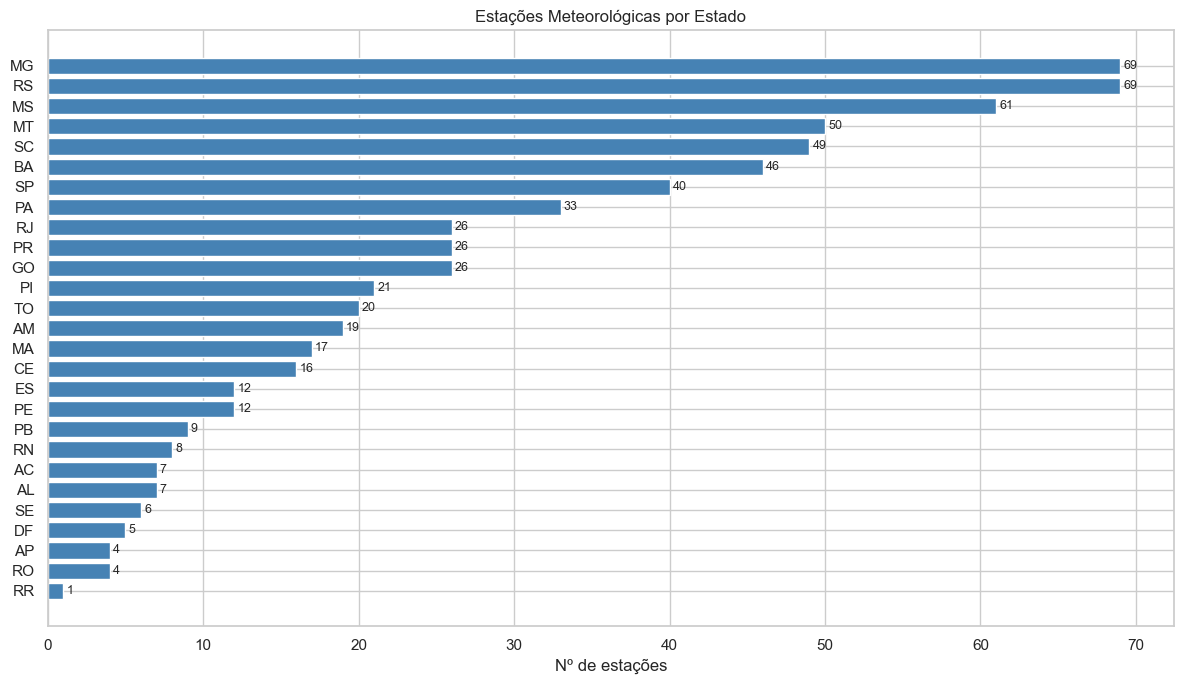

In [15]:
by_state = stations['state'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(by_state.index, by_state.values, color='steelblue')
ax.set_xlabel('Nº de estações')
ax.set_title('Estações Meteorológicas por Estado')
for i, v in enumerate(by_state.values):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 3.2 Distribuição de Altitude

Histograma das altitudes de todas as estações.

**O que esperar:** maioria das estações entre 0 e 1000 m. Pouquíssimas acima de 1500 m.

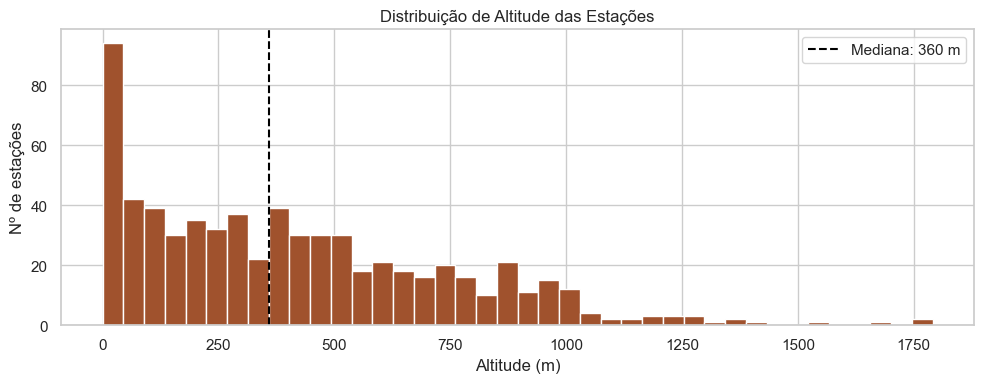

count     663.0
mean      409.7
std       335.1
min         0.0
25%       122.8
50%       360.0
75%       621.6
max      1790.4
Name: altitude, dtype: float64


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stations['altitude'].dropna(), bins=40, color='sienna', edgecolor='white')
ax.axvline(stations['altitude'].median(), color='black', linestyle='--',
           label=f'Mediana: {stations["altitude"].median():.0f} m')
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('Nº de estações')
ax.set_title('Distribuição de Altitude das Estações')
ax.legend()
plt.tight_layout()
plt.show()
print(stations['altitude'].describe().round(1))

### 3.3 Altitude × Temperatura Média e Pressão Média

Valida o gradiente altimétrico: temperatura deve cair ~6.5°C/km e pressão deve diminuir com altitude.

**O que esperar:** correlação negativa clara nos dois gráficos, com regressão linear decrescente.

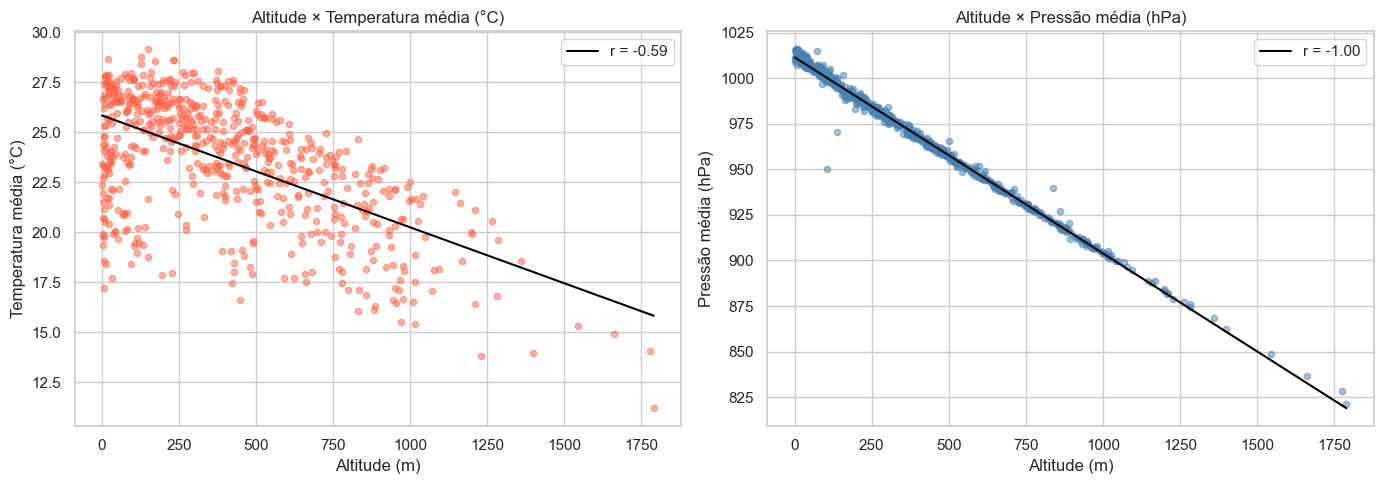

In [17]:
station_means = measurements.groupby('station_code')[['temperature', 'pressure']].mean()
station_means = station_means.merge(stations[['code', 'altitude']], left_index=True, right_on='code')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in [
    (axes[0], 'temperature', 'tomato',    'Temperatura média (°C)'),
    (axes[1], 'pressure',    'steelblue', 'Pressão média (hPa)'),
]:
    valid = station_means[['altitude', col]].dropna()
    ax.scatter(valid['altitude'], valid[col], alpha=0.5, s=20, color=color)
    slope_v, intercept_v, r_v, *_ = stats.linregress(valid['altitude'], valid[col])
    xs = np.linspace(valid['altitude'].min(), valid['altitude'].max(), 100)
    ax.plot(xs, slope_v * xs + intercept_v, color='black', linewidth=1.5, label=f'r = {r_v:.2f}')
    ax.set_xlabel('Altitude (m)')
    ax.set_ylabel(label)
    ax.set_title(f'Altitude × {label}')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Mapa do Brasil — Completude dos Dados por Estação

Cada ponto representa uma estação meteorológica. A cor indica o percentual médio de dados
não-nulos: **verde = dados completos**, **amarelo = parcialmente incompleto**, **vermelho = crítico**.

**O que esperar:** regiões da Amazônia e Norte do Brasil com mais estações em vermelho,
enquanto Sul e Sudeste tendem a ter melhor cobertura.

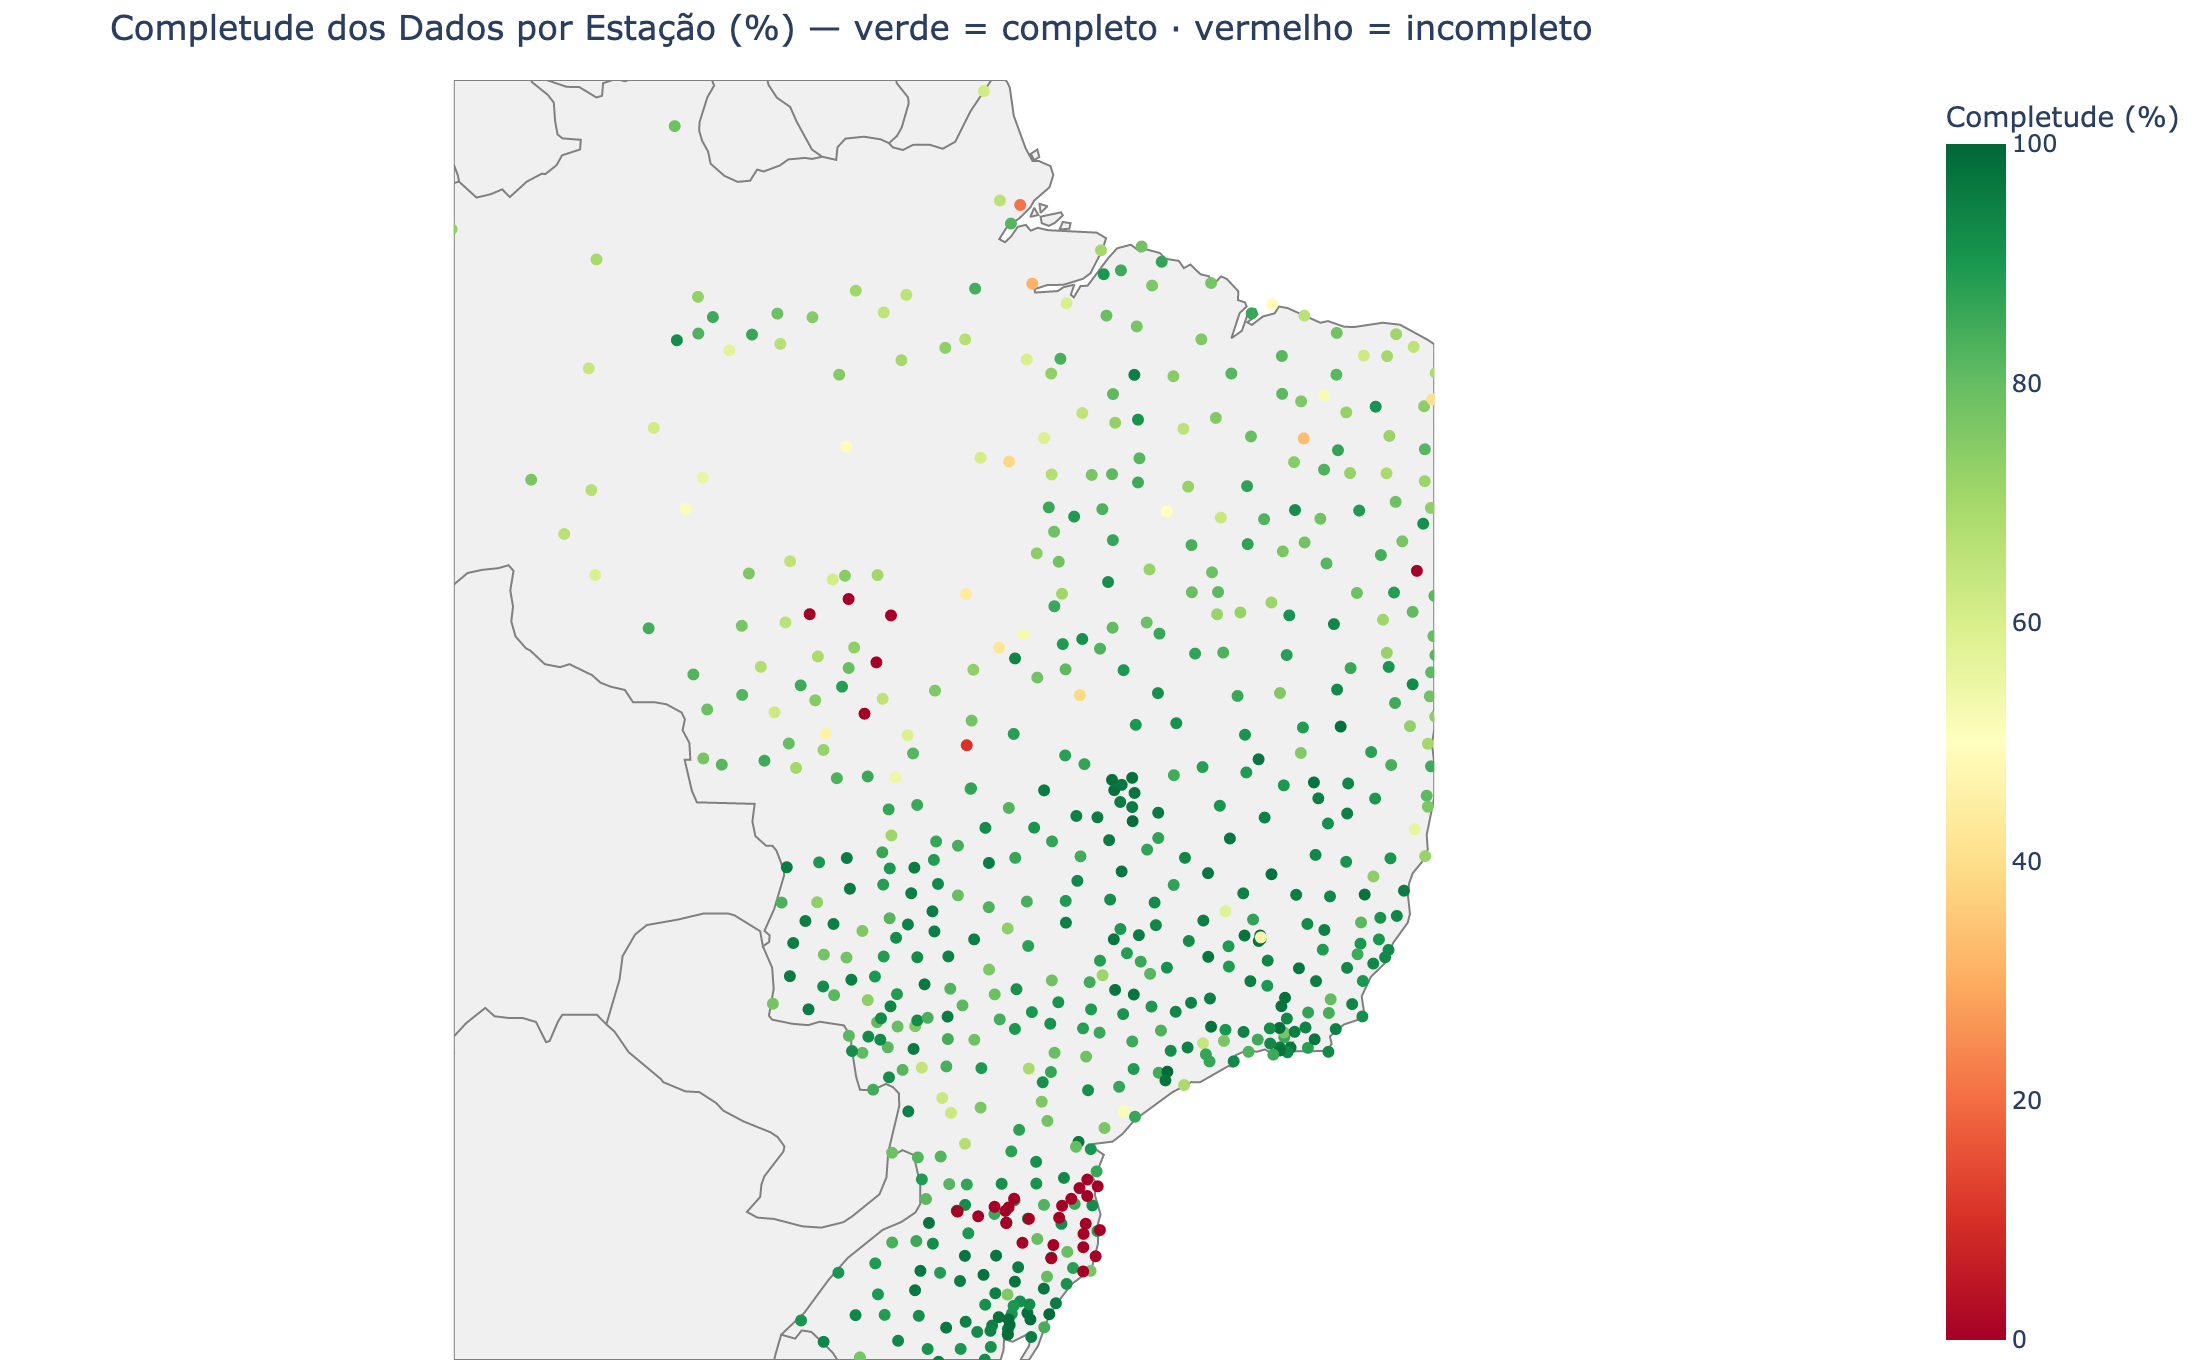

In [18]:
from IPython.display import Image, display

completeness = (
    measurements.groupby('station_code')[MEASURE_COLS]
    .apply(lambda x: (1 - x.isnull().mean()).mean() * 100)
    .rename('completeness_pct')
)
station_map = stations.merge(completeness, left_on='code', right_index=True, how='left')
station_map['completeness_pct'] = station_map['completeness_pct'].fillna(0).round(1)

fig = px.scatter_geo(
    station_map,
    lat='latitude', lon='longitude',
    color='completeness_pct',
    color_continuous_scale='RdYlGn',
    range_color=[0, 100],
    size_max=10,
    hover_name='name',
    hover_data={'code': True, 'state': True, 'altitude': True,
                'completeness_pct': ':.1f', 'latitude': False, 'longitude': False},
    scope='south america',
    title='Completude dos Dados por Estação (%) — verde = completo · vermelho = incompleto',
    labels={'completeness_pct': 'Completude (%)'},
)
fig.update_layout(
    geo=dict(showland=True, landcolor='#f0f0f0', showcountries=True,
             countrycolor='gray', center=dict(lat=-14, lon=-53), projection_scale=2.5),
    margin=dict(l=0, r=0, t=40, b=0),
    height=650,
)
fig.show()

# Versão estática para o PDF (requer kaleido: pip install kaleido)
try:
    display(Image(fig.to_image(format='png', width=1100, height=680, scale=2)))
except Exception:
    print('Mapa estático indisponível — instale kaleido: pip install kaleido')

---
## 4. Análise Climatológica

Esta seção explora os padrões temporais e as relações entre as variáveis meteorológicas,
incluindo sazonalidade, tendência de longo prazo, ciclo diurno e correlações.

### 4.1 Sazonalidade — Médias Mensais

Mostra como cada variável se comporta ao longo dos meses do ano, agregando toda a série histórica.

**O que esperar:** temperatura mais alta no verão austral (dez–fev), chuva concentrada no mesmo período,
radiação solar com pico no verão, umidade inversamente correlacionada com a temperatura no inverno seco.

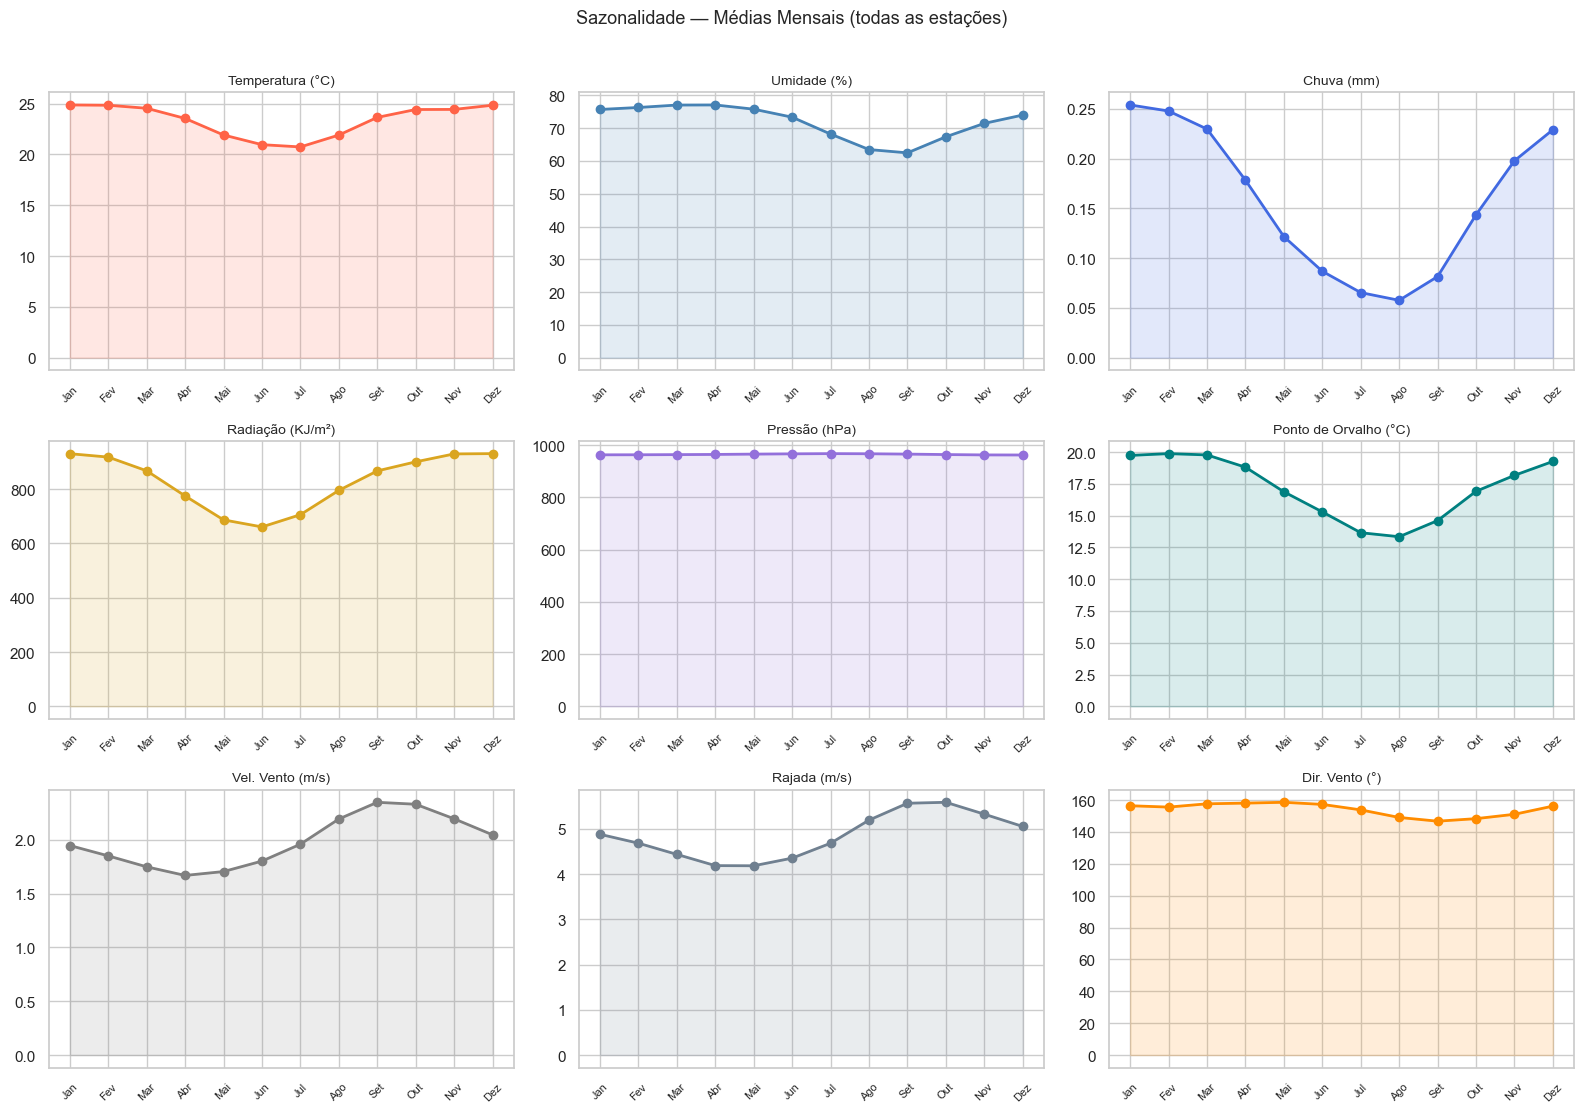

In [19]:
monthly = measurements.groupby('month')[MEASURE_COLS].mean()
month_labels = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(3, 3, figsize=(16, 11))

for ax, col, color in zip(axes.flat, MEASURE_COLS, colors):
    ax.plot(month_labels, monthly[col], marker='o', color=color, linewidth=2)
    ax.fill_between(range(12), monthly[col], alpha=0.15, color=color)
    ax.set_title(MEASURE_LABELS[col], fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('Sazonalidade — Médias Mensais (todas as estações)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Tendência de Temperatura ao Longo do Tempo

Analisa a evolução da temperatura média anual de 2000 a 2025.
Com 25 anos de dados cobrindo todo o Brasil, deve ser possível detectar o sinal de
aquecimento climático na série histórica.

A regressão linear quantifica a taxa de mudança em °C/ano e o p-valor indica se a tendência
é estatisticamente significativa ou pode ser atribuída ao acaso.

**O que esperar:** tendência positiva (aquecimento) com slope entre 0.01 e 0.05°C/ano,
consistente com o aquecimento global observado no Brasil. p-valor < 0.05 confirma significância.

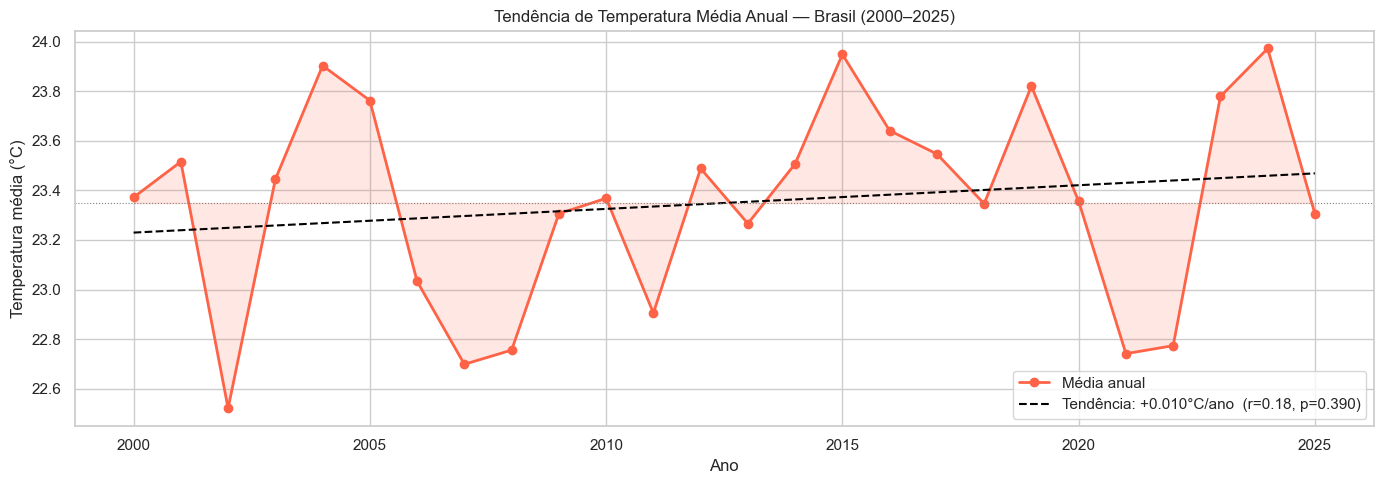

Variação total estimada  : +0.24°C ao longo do período
Slope                    : +0.0096°C/ano
R²                       : 0.031
p-valor                  : 0.3895  ✗ não significativo


In [20]:
annual_temp = measurements.groupby('year')['temperature'].mean().dropna()

slope, intercept, r, p_val, _ = stats.linregress(annual_temp.index, annual_temp.values)
trend_line = slope * annual_temp.index + intercept

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(annual_temp.index, annual_temp.values, marker='o', color='tomato',
        linewidth=2, label='Média anual')
ax.fill_between(annual_temp.index, annual_temp.values,
                annual_temp.mean(), alpha=0.15, color='tomato')
ax.plot(annual_temp.index, trend_line, color='black', linewidth=1.5, linestyle='--',
        label=f'Tendência: {slope:+.3f}°C/ano  (r={r:.2f}, p={p_val:.3f})')
ax.axhline(annual_temp.mean(), color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Ano')
ax.set_ylabel('Temperatura média (°C)')
ax.set_title('Tendência de Temperatura Média Anual — Brasil (2000–2025)')
ax.legend()
plt.tight_layout()
plt.show()

total_change = slope * (annual_temp.index[-1] - annual_temp.index[0])
print(f'Variação total estimada  : {total_change:+.2f}°C ao longo do período')
print(f'Slope                    : {slope:+.4f}°C/ano')
print(f'R²                       : {r**2:.3f}')
print(f'p-valor                  : {p_val:.4f}  {"✓ significativo" if p_val < 0.05 else "✗ não significativo"}')

### 4.3 Ciclo Diurno — Médias por Hora UTC

Mostra como cada variável varia ao longo das 24 horas do dia (em UTC).

**O que esperar:** temperatura com pico entre 18–21 UTC (15–18 BRT, tarde),
radiação solar zerando à noite, umidade com padrão inverso à temperatura.

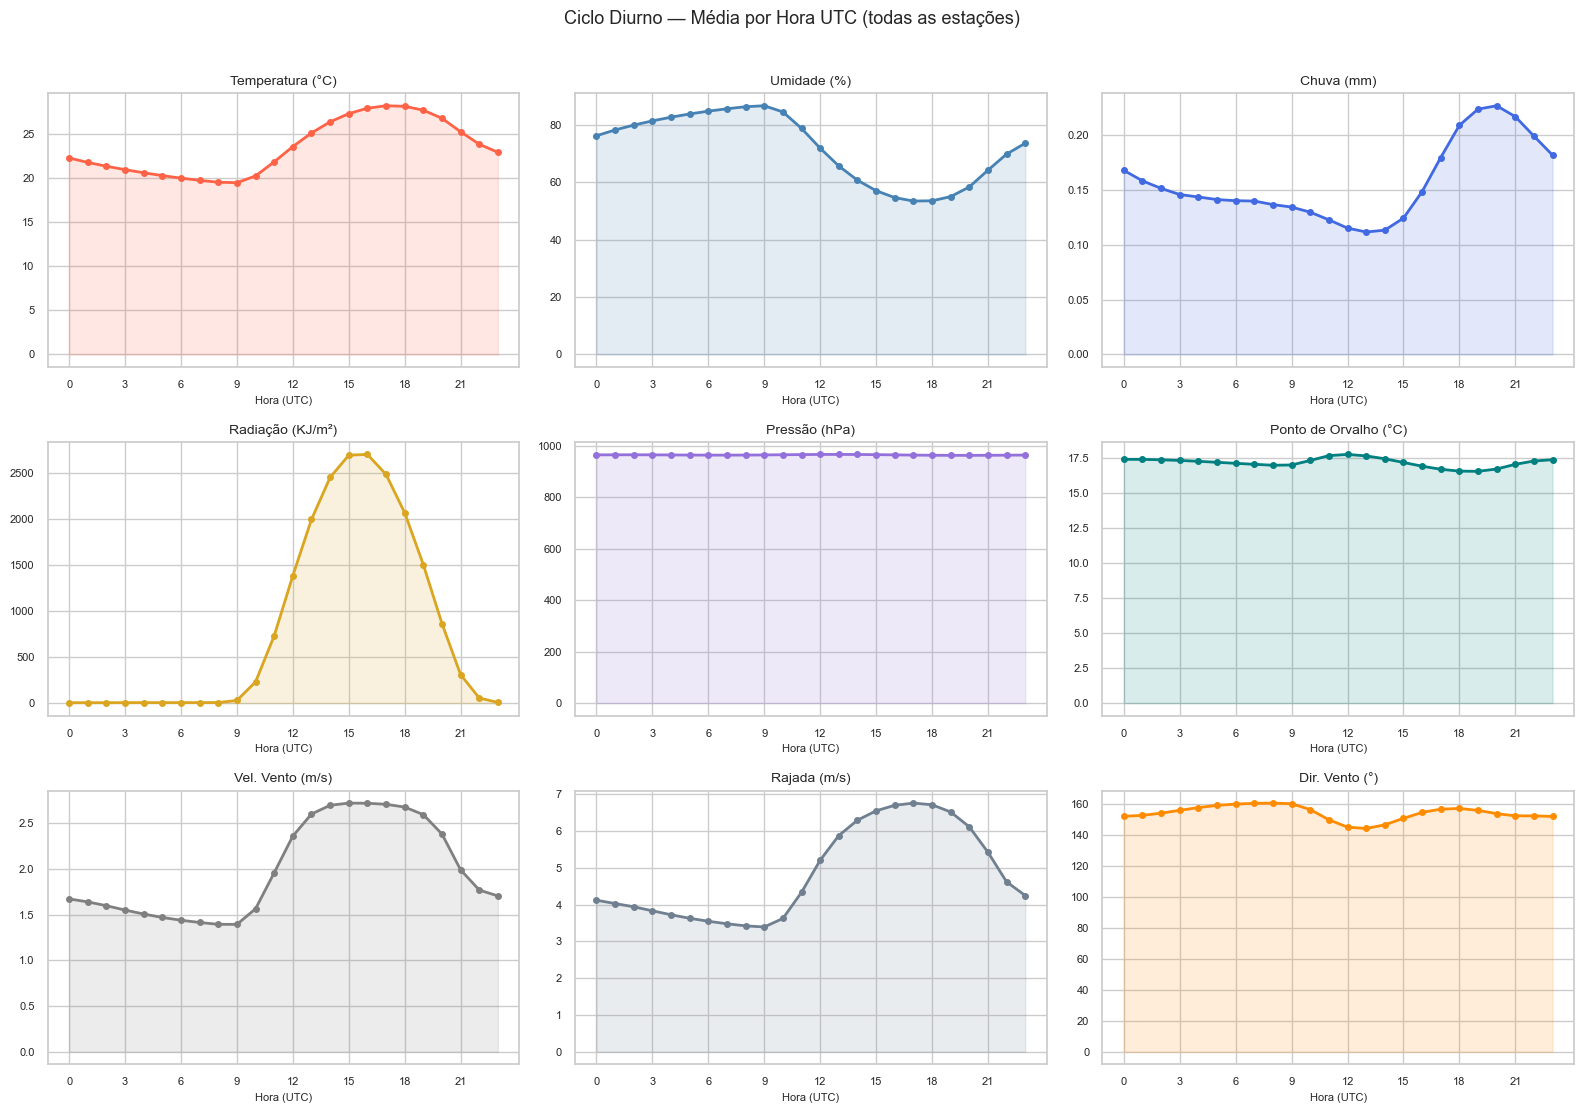

In [21]:
hourly = measurements.groupby('hour')[MEASURE_COLS].mean()

fig, axes = plt.subplots(3, 3, figsize=(16, 11))

for ax, col, color in zip(axes.flat, MEASURE_COLS, colors):
    ax.plot(hourly.index, hourly[col], marker='o', color=color, linewidth=2, markersize=4)
    ax.fill_between(hourly.index, hourly[col], alpha=0.15, color=color)
    ax.set_title(MEASURE_LABELS[col], fontsize=10)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel('Hora (UTC)', fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle('Ciclo Diurno — Média por Hora UTC (todas as estações)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Distribuição de Chuva

A chuva tem distribuição muito diferente das outras variáveis: a maioria das horas é seca
(rainfall = 0) e os eventos seguem distribuição exponencial ou gamma.

**O que esperar:** mais de 90% das horas com chuva zero. Eventos acima de 10 mm/h já são intensos.

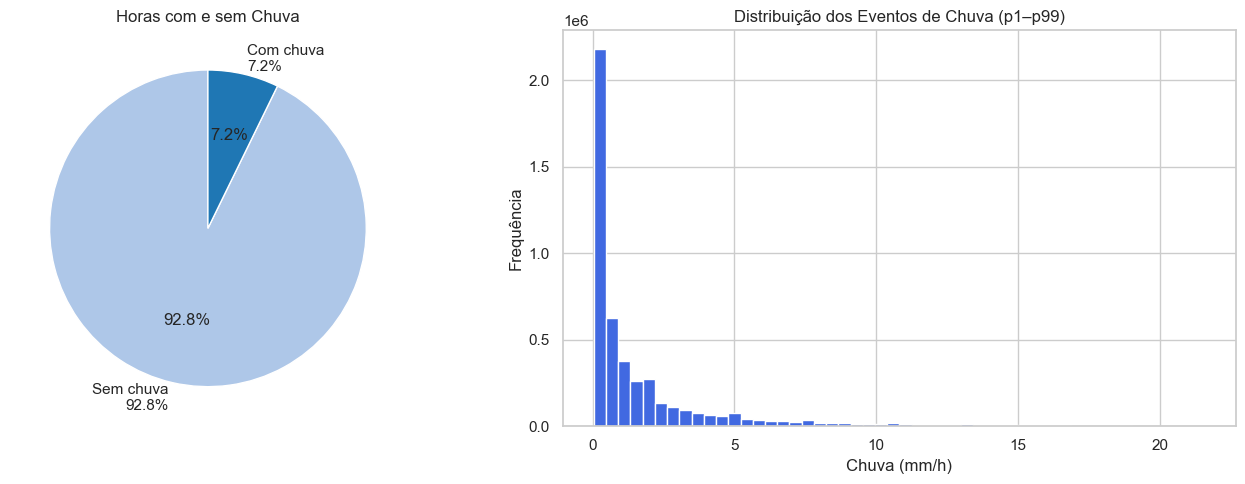


Top 10 estações mais chuvosas (média mm/h):
                                 name state  rainfall
                       NOVA XAVANTINA    MT  1.113333
                            ITANHANGA    MT  0.580608
                           DIAMANTINO    MT  0.498824
                   LUCAS DO RIO VERDE    MT  0.414583
                            COCALINHO    MT  0.411905
                                BELEM    PA  0.394574
                             OIAPOQUE    AP  0.341101
                   S. G. DA CACHOEIRA    AM  0.337583
BOM JARDIM DA SERRA - MORRO DA IGREJA    SC  0.335247
          TERESOPOLIS-PARQUE NACIONAL    RJ  0.327917


In [22]:
rain = measurements['rainfall'].dropna()
pct_zero    = (rain == 0).mean() * 100
pct_nonzero = 100 - pct_zero

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie([pct_zero, pct_nonzero],
            labels=[f'Sem chuva\n{pct_zero:.1f}%', f'Com chuva\n{pct_nonzero:.1f}%'],
            colors=['#aec7e8', '#1f77b4'], startangle=90, autopct='%1.1f%%')
axes[0].set_title('Horas com e sem Chuva')

rain_events = rain[rain > 0]
axes[1].hist(rain_events[rain_events < rain_events.quantile(0.99)],
             bins=50, color='royalblue', edgecolor='white')
axes[1].set_xlabel('Chuva (mm/h)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Eventos de Chuva (p1–p99)')
plt.tight_layout()
plt.show()

top_rain = (measurements.groupby('station_code')['rainfall'].mean()
            .sort_values(ascending=False).head(10).reset_index()
            .merge(stations[['code','name','state']], left_on='station_code', right_on='code'))
print('\nTop 10 estações mais chuvosas (média mm/h):')
print(top_rain[['name','state','rainfall']].to_string(index=False))

### 4.5 Rosa dos Ventos

`wind_direction` é uma variável **circular** (0° e 360° são o mesmo ponto) e não pode ser
analisada com histograma convencional — 359° e 1° estão a 2° de distância, não a 358°.
A rosa dos ventos é a visualização correta: mostra a frequência de ocorrência por direção
e a intensidade (cor) indica a velocidade média do vento naquela direção.

**O que esperar:** ventos predominantes do quadrante leste/nordeste no Brasil,
influenciados pelos alísios. Variações regionais significativas entre litoral e interior.

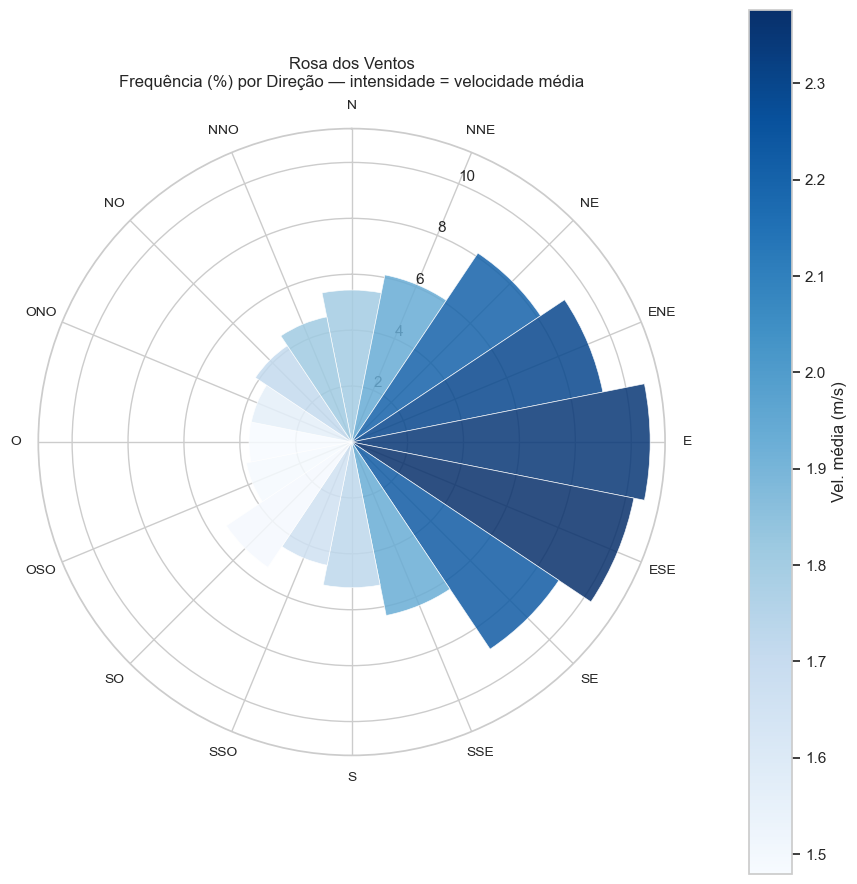

Direção mais frequente : E  (10.7%)
Velocidade média geral : 1.99 m/s


In [23]:
wind = measurements[['wind_direction', 'wind_speed']].dropna()
wind = wind[(wind['wind_direction'] >= 0) & (wind['wind_direction'] <= 360)]

n_dirs    = 16
dir_width = 360 / n_dirs
dir_labels = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
              'S','SSO','SO','OSO','O','ONO','NO','NNO']

dir_edges  = np.arange(-dir_width / 2, 360, dir_width)
wind['bin'] = pd.cut(wind['wind_direction'], bins=dir_edges, labels=False)
wind['bin'] = wind['bin'].fillna(0).astype(int)

freq     = wind.groupby('bin').size() / len(wind) * 100
mean_spd = wind.groupby('bin')['wind_speed'].mean()
freq     = freq.reindex(range(n_dirs), fill_value=0.0)
mean_spd = mean_spd.reindex(range(n_dirs), fill_value=0.0)

angles = np.radians(np.arange(0, 360, dir_width))

fig = plt.figure(figsize=(9, 9))
ax  = fig.add_subplot(111, projection='polar')
ax.set_theta_direction(-1)
ax.set_theta_zero_location('N')

norm       = plt.Normalize(mean_spd.min(), mean_spd.max())
bar_colors = plt.cm.Blues(norm(mean_spd.values))

ax.bar(angles, freq.values, width=np.radians(dir_width),
       color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, pad=0.1, label='Vel. média (m/s)')

ax.set_xticks(angles)
ax.set_xticklabels(dir_labels, fontsize=10)
ax.set_title('Rosa dos Ventos\nFrequência (%) por Direção — intensidade = velocidade média',
             pad=30, fontsize=12)
plt.tight_layout()
plt.show()

print(f'Direção mais frequente : {dir_labels[int(freq.argmax())]}  ({freq.max():.1f}%)')
print(f'Velocidade média geral : {wind["wind_speed"].mean():.2f} m/s')

### 4.6 Extremos Históricos por Variável

Identifica o maior e menor valor já registrado em cada variável, com a estação e a data do evento.

**O que esperar:** temperatura máxima acima de 40°C no interior do Nordeste, mínimas abaixo de 0°C
no Sul. Chuvas extremas próximas a 200–300 mm/h em eventos convectivos severos.

In [24]:
for col in ['temperature', 'humidity', 'rainfall', 'wind_gust', 'pressure']:
    idx_max = measurements[col].idxmax()
    idx_min = measurements[col].idxmin()
    rmax = measurements.loc[idx_max]
    rmin = measurements.loc[idx_min]
    print(f'{MEASURE_LABELS[col]}')
    print(f'  MAX  {rmax[col]:.2f}   estação {rmax["station_code"]}  em {str(rmax["measurement_time"].date())}')
    print(f'  MIN  {rmin[col]:.2f}   estação {rmin["station_code"]}  em {str(rmin["measurement_time"].date())}')
    print()

Temperatura (°C)
  MAX  45.00   estação A053  em 2021-07-11
  MIN  -9.60   estação A861  em 2011-04-15

Umidade (%)
  MAX  100.00   estação A101  em 2001-11-04
  MIN  7.00   estação A923  em 2019-05-16

Chuva (mm)
  MAX  138.20   estação A348  em 2022-05-20
  MIN  0.00   estação A001  em 2000-05-07

Rajada (m/s)
  MAX  50.00   estação A506  em 2025-08-06
  MIN  0.00   estação A601  em 2000-08-20

Pressão (hPa)
  MAX  1050.00   estação A604  em 2012-03-21
  MIN  802.00   estação A845  em 2023-07-13



### 4.7 Matriz de Correlação Completa entre Variáveis

Mede o grau de associação linear entre todos os pares de variáveis meteorológicas.
A diagonal principal sempre vale **1.0**. Cores quentes (vermelho) = correlação positiva forte;
cores frias (azul) = correlação negativa forte.

**O que esperar:**
- `temperature` × `dew_point`: alta positiva (~0.85+)
- `temperature` × `humidity`: negativa moderada
- `wind_speed` × `wind_gust`: muito alta (~0.95+)
- `global_radiation` × `temperature`: positiva

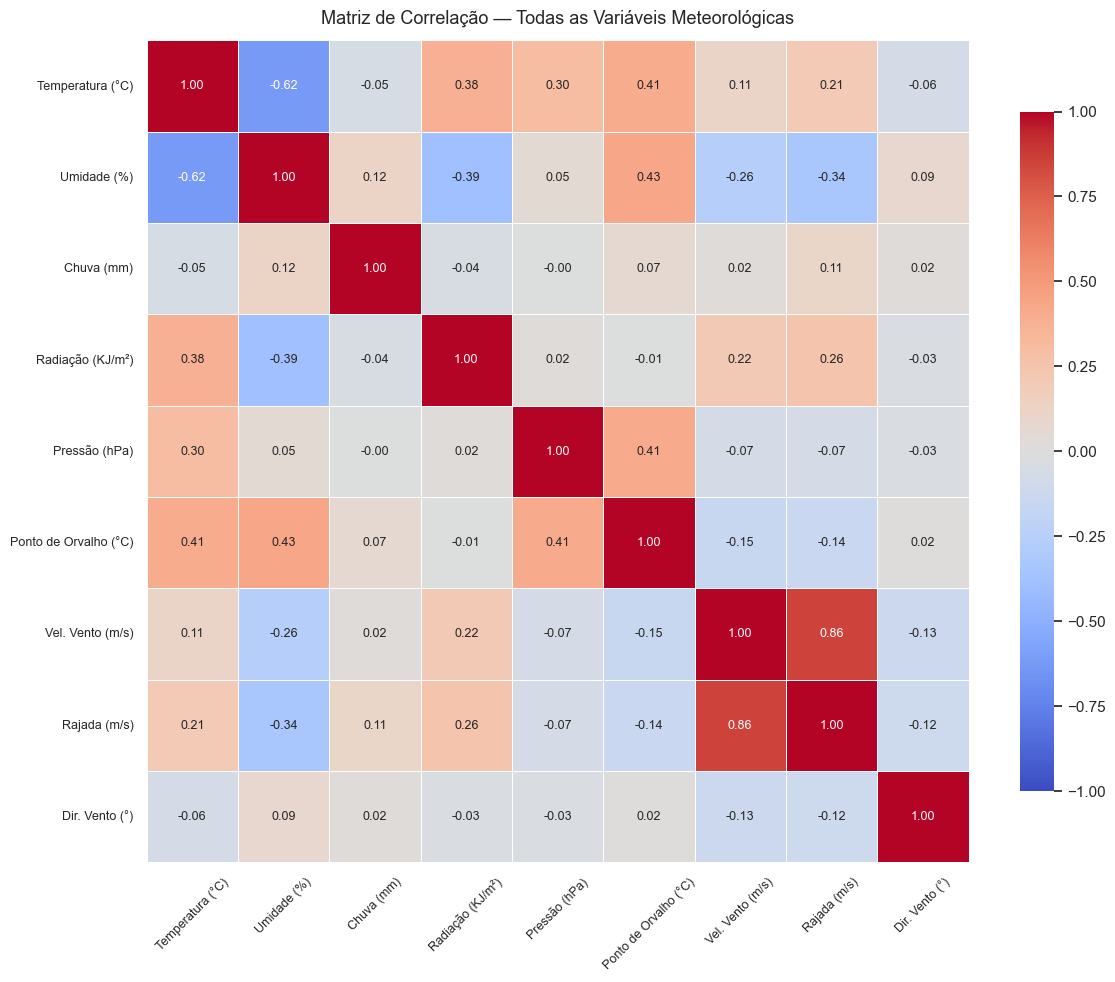

In [25]:
sample_corr = measurements[MEASURE_COLS].dropna().sample(min(200_000, len(measurements)), random_state=42)
corr = sample_corr.corr()
corr.index   = [MEASURE_LABELS[c] for c in corr.index]
corr.columns = [MEASURE_LABELS[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, linewidths=0.5,
    square=True, ax=ax, annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Matriz de Correlação — Todas as Variáveis Meteorológicas', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

### 4.8 Scatter Plots — Pares com Alta Correlação

Visualiza a relação entre os pares de variáveis mais correlacionados identificados na matriz acima.
Permite confirmar se a relação é linear, verificar heteroscedasticidade e identificar agrupamentos.

**O que esperar:** `temperature` × `dew_point` com nuvem densa e bem alinhada.
`wind_speed` × `wind_gust` com relação quase perfeita.

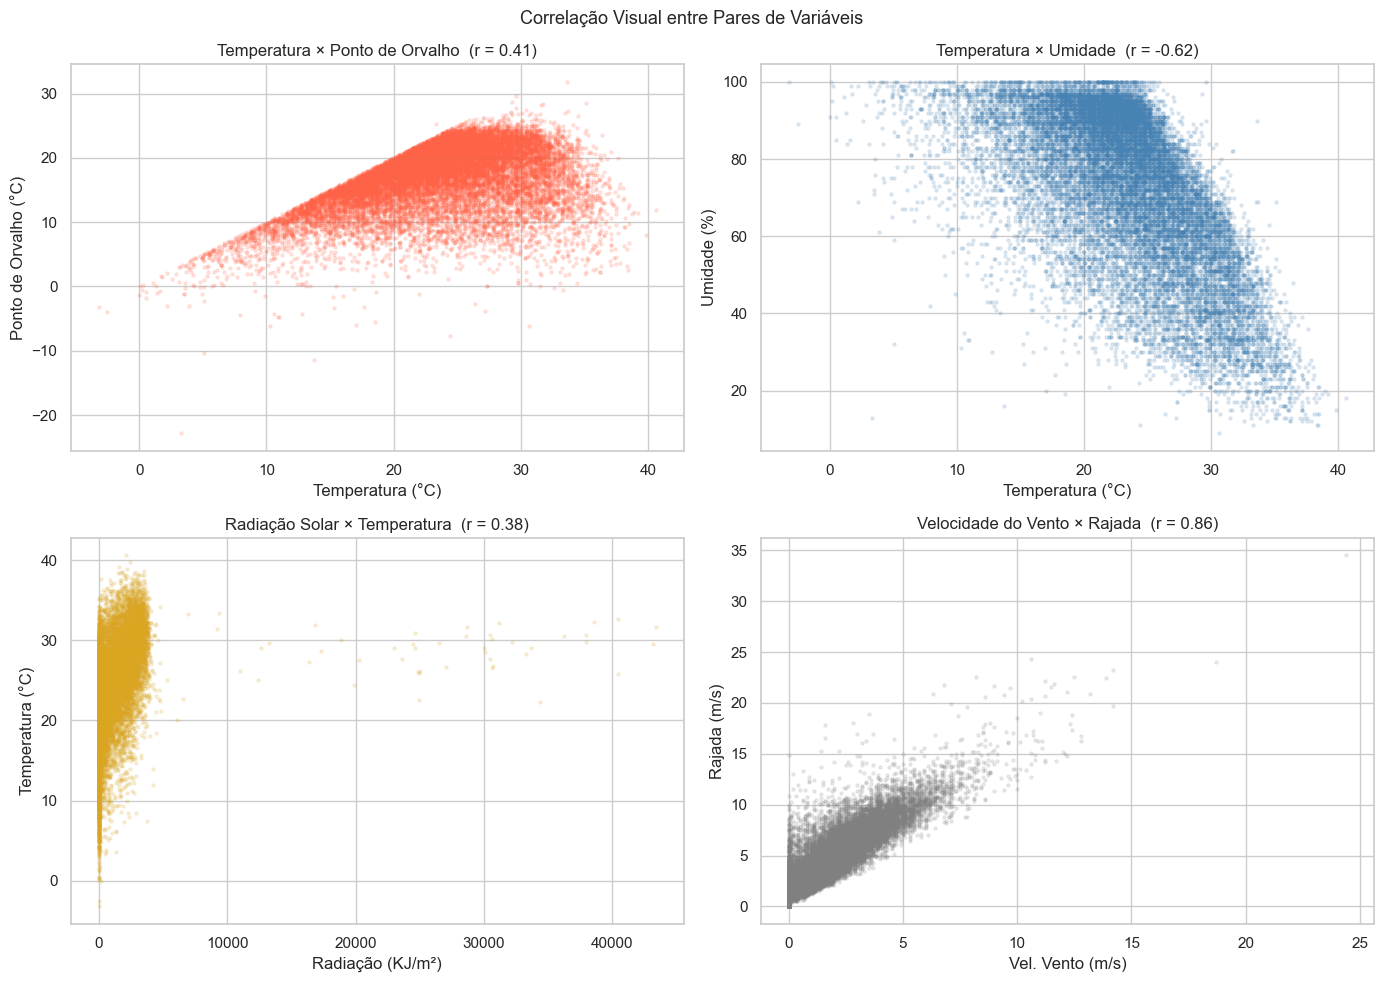

In [26]:
scatter_pairs = [
    ('temperature',      'dew_point',   'tomato',    'Temperatura × Ponto de Orvalho'),
    ('temperature',      'humidity',    'steelblue', 'Temperatura × Umidade'),
    ('global_radiation', 'temperature', 'goldenrod', 'Radiação Solar × Temperatura'),
    ('wind_speed',       'wind_gust',   'gray',      'Velocidade do Vento × Rajada'),
]

s20k = measurements[MEASURE_COLS].dropna().sample(20_000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (x, y, color, title) in zip(axes.flat, scatter_pairs):
    ax.scatter(s20k[x], s20k[y], alpha=0.15, s=5, color=color)
    r = s20k[[x, y]].corr().iloc[0, 1]
    ax.set_xlabel(MEASURE_LABELS[x])
    ax.set_ylabel(MEASURE_LABELS[y])
    ax.set_title(f'{title}  (r = {r:.2f})')

fig.suptitle('Correlação Visual entre Pares de Variáveis', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Similaridade entre Estações

Esta seção analisa como as estações se relacionam entre si em termos de proximidade geográfica
e similaridade climática — base para a escolha de estações proxy no gap-filling.

### 5.1 Correlação de Temperatura vs. Distância Efetiva

Valida a hipótese central do projeto: estações mais próximas em `effective_distance_km`
devem ter temperaturas mais correlacionadas.

**O que esperar:** correlação decrescente com o aumento da distância efetiva.
Pares abaixo de 50 km devem ter correlação acima de 0.90.

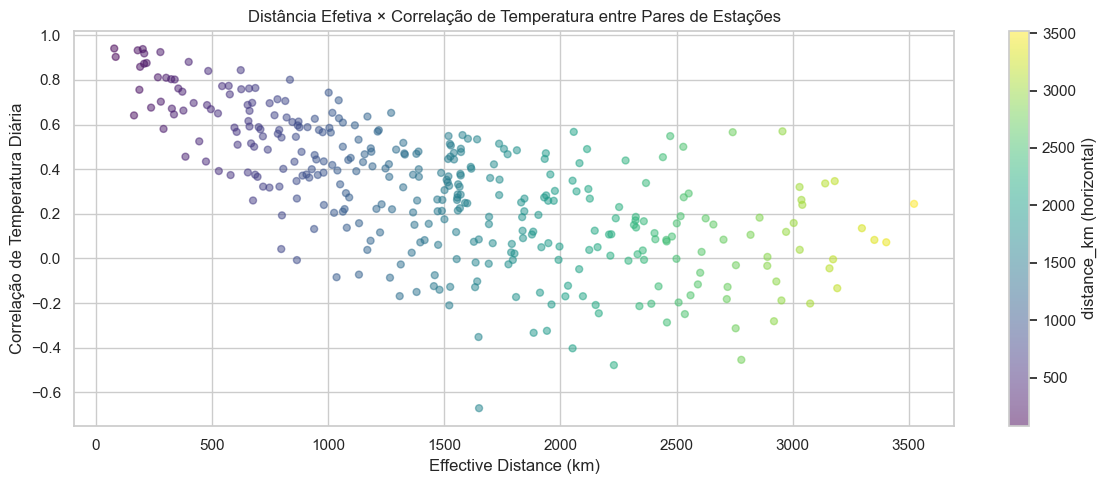

In [32]:
daily_temp = (
    measurements.groupby(['station_code', measurements['measurement_time'].dt.date])['temperature']
    .mean().unstack(level=0)
)

dist_reset   = distances.reset_index()
sample_pairs = dist_reset.sample(min(400, len(dist_reset)), random_state=42)

results = []
for _, row in sample_pairs.iterrows():
    a, b = row['from_code'], row['to_code']
    if a in daily_temp.columns and b in daily_temp.columns:
        r = daily_temp[[a, b]].dropna().corr().iloc[0, 1]
        results.append({'effective_distance_km': row['effective_distance_km'],
                        'distance_km': row['distance_km'],
                        'correlation': r})

corr_df = pd.DataFrame(results).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(corr_df['effective_distance_km'], corr_df['correlation'],
                alpha=0.5, s=25, c=corr_df['distance_km'], cmap='viridis')
plt.colorbar(sc, ax=ax, label='distance_km (horizontal)')
ax.set_xlabel('Effective Distance (km)')
ax.set_ylabel('Correlação de Temperatura Diária')
ax.set_title('Distância Efetiva × Correlação de Temperatura entre Pares de Estações')
plt.tight_layout()
plt.show()

### 5.2 Correlação Média por Faixa de Distância Efetiva

Agrega os pares em faixas e mostra a correlação média por faixa.
O ponto de inflexão define o raio ideal de busca de estações proxy.

**O que esperar:** queda progressiva estabilizando próxima de 0.5–0.6 para grandes distâncias.

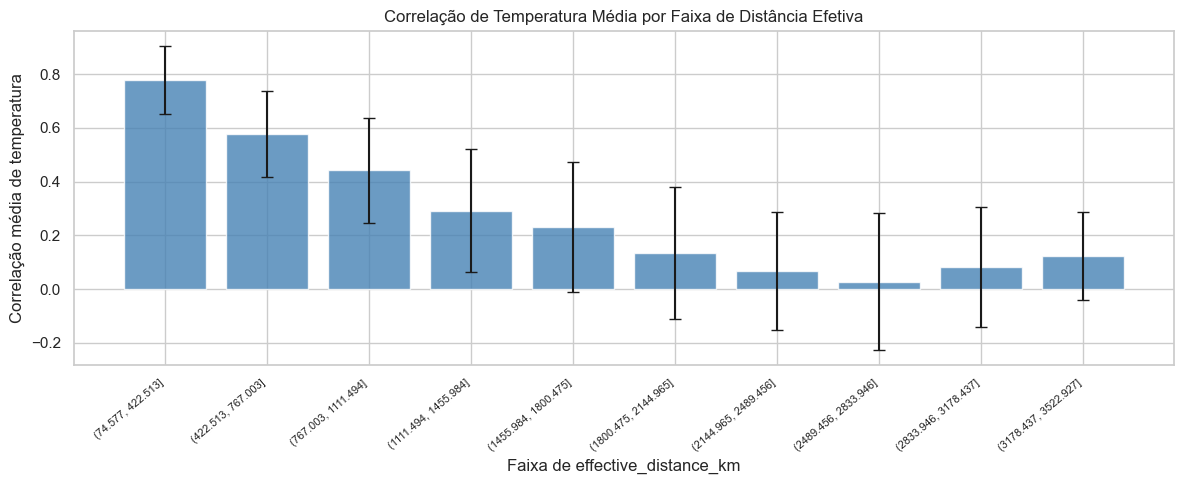

In [33]:
if len(corr_df) > 0:
    bins   = pd.cut(corr_df['effective_distance_km'], bins=10)
    grouped = corr_df.groupby(bins, observed=True)['correlation'].agg(['mean', 'std', 'count'])

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(grouped)), grouped['mean'], yerr=grouped['std'],
           capsize=4, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(i) for i in grouped.index], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Correlação média de temperatura')
    ax.set_xlabel('Faixa de effective_distance_km')
    ax.set_title('Correlação de Temperatura Média por Faixa de Distância Efetiva')
    plt.tight_layout()
    plt.show()

### 5.3 Clustering de Estações por Perfil Climático

Agrupa as estações em clusters com base em suas médias históricas de temperatura, umidade,
chuva, radiação e vento. Cada cluster representa um regime climático distinto.

**O que esperar:** clusters separando claramente Amazônia (quente e úmido), Nordeste semiárido
(quente e seco), Sul (temperado), Cerrado e Mata Atlântica.

Perfil médio por cluster:
         temperature  humidity  rainfall  global_radiation  wind_speed  altitude
cluster                                                                         
0               19.0      78.0       0.2             726.9         2.5     557.7
1               26.0      67.5       0.1             865.3         2.4     271.0
2               23.4      68.4       0.1             798.2         2.0     530.9
3               26.1      78.1       0.2             759.1         1.3     150.9
4               25.3      71.8       0.2            2727.7         2.2     341.8


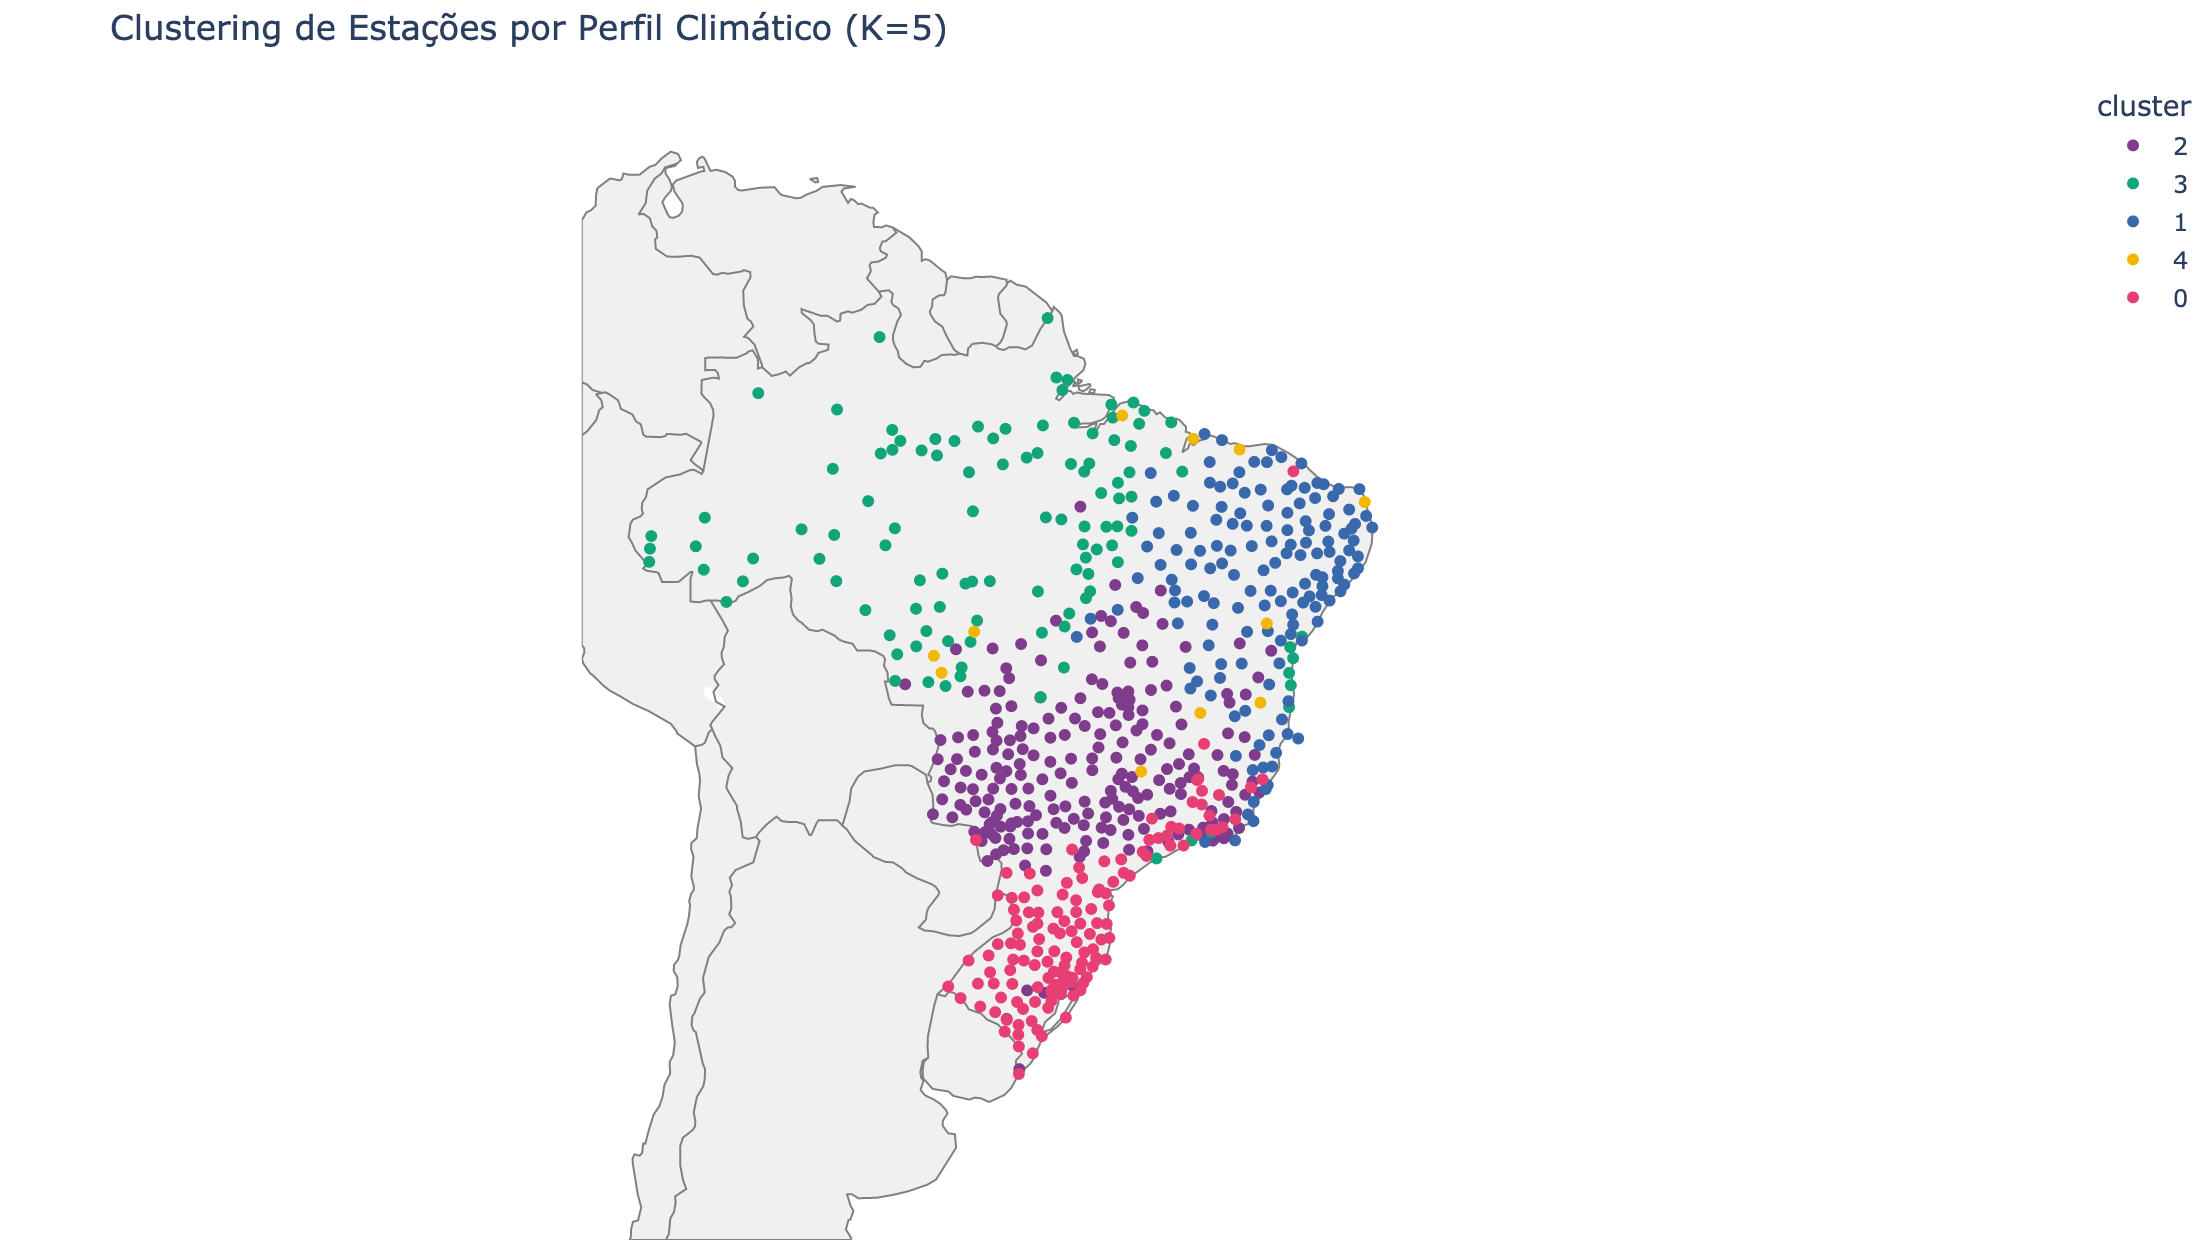

In [34]:
from IPython.display import Image, display

profile_cols = ['temperature', 'humidity', 'rainfall', 'global_radiation', 'wind_speed']
station_profile = measurements.groupby('station_code')[profile_cols].mean()
station_profile = station_profile.merge(
    stations[['code', 'altitude', 'latitude', 'longitude']],
    left_index=True, right_on='code'
).set_index('code').dropna()

X = StandardScaler().fit_transform(station_profile)
station_profile['cluster'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)
station_profile['cluster'] = station_profile['cluster'].astype(str)

print('Perfil médio por cluster:')
print(station_profile.groupby('cluster')[profile_cols + ['altitude']].mean().round(1).to_string())

fig = px.scatter_geo(
    station_profile.reset_index(),
    lat='latitude', lon='longitude',
    color='cluster',
    hover_name='code',
    hover_data={'altitude': True, 'temperature': ':.1f', 'rainfall': ':.2f'},
    scope='south america',
    title='Clustering de Estações por Perfil Climático (K=5)',
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(
    geo=dict(showland=True, landcolor='#f0f0f0', showcountries=True,
             countrycolor='gray', center=dict(lat=-14, lon=-53), projection_scale=1.5),
    margin=dict(l=0, r=0, t=40, b=0),
    height=600,
)
fig.show()

# Versão estática para o PDF (requer kaleido==0.2.1: pip install "kaleido==0.2.1")
try:
    display(Image(fig.to_image(format='png', width=1100, height=620, scale=2)))
except Exception:
    print('Mapa estático indisponível — instale kaleido: pip install "kaleido==0.2.1"')

---
## 6. Exportar para PDF

Exporta este notebook para HTML e converte para PDF usando `weasyprint`.
Execute esta célula após rodar todas as anteriores.

> **Pré-requisito:** `pip install weasyprint`

In [35]:
import subprocess

notebook = '1.3_exploratory_analysis.ipynb'
html_out = notebook.replace('.ipynb', '.html')
pdf_out  = notebook.replace('.ipynb', '.pdf')

print('Convertendo notebook para HTML...')
result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html', '--no-input', notebook],
    capture_output=True, text=True
)
if result.returncode != 0:
    print('ERRO ao converter:', result.stderr)
else:
    print(f'HTML gerado: {html_out}')
    print('Convertendo HTML para PDF...')
    try:
        from weasyprint import HTML
        HTML(html_out).write_pdf(pdf_out)
        print(f'PDF gerado: {pdf_out}')
    except ImportError:
        print('weasyprint não instalado. Rode: pip install weasyprint')
    except Exception as e:
        print(f'Erro ao gerar PDF: {e}')

Convertendo notebook para HTML...
HTML gerado: 1.3_exploratory_analysis.html
Convertendo HTML para PDF...
PDF gerado: 1.3_exploratory_analysis.pdf
